## Stock Trading using Reinforcement Learning

### Importing and Processing Data 

In [37]:
%load_ext autoreload
%autoreload 2

In [111]:
from pandas import read_csv
import pandas as pd
import numpy as np
stock_data = read_csv('aapl_msi_sbux.csv')
stock_data = np.array(stock_data)

In [112]:
n_rows = len(stock_data)
n_stocks = len(stock_data[0])
print(n_rows)
print(n_stocks)

1259
3


### Data Randomization Logic

Given the data here is sequential, it made sense to take the data in order.

Here, the data is split 80% for actually training the model and fixing the Q values, then the final 20% is the test set that these Q values are applied to.



In [113]:
# split data into train and test sets
def train_test(data):
  # split data
  split = int(0.8*len(data))
  train = data[:split]
  test = data[split:]
  print(split)
  # scale both train and test using train mean and std
  train_mean = train.mean(axis=0)
  train_std = train.std(axis=0)
  train_norm = (train-train_mean)/train_std
  test_norm = (test-train_mean)/train_std
  return train_norm, test_norm

train_norm, test_norm = train_test(stock_data)
# quick check
print(train_norm.mean(axis=0))

1007
[-3.95137966e-16 -1.69344843e-16  4.51586247e-16]


### Annualization

Portfolios are annualized for a fair comparison

The standard formula for compounding is:
\begin{equation*}
       P_{T} = P_{0}(1+r)^{T/252}
\end{equation*}

$P_{annual} = P_{0}(1+r)$

Therefore $P_{annual} = P_{0}\left(\frac{P_{T}}{P_{0}}\right)^{252/T}$

In [114]:
def annualization(original, time, principal):
  return np.round(principal*(original/principal)**(252/time),2)

## Overall mechanism

A basic model is tried first.

This is because with only 1000 trading days in data, a small state action space is needed to make sure the model can actually adapt to the conditions provided.

For now, only try the AAPL stock, buy sell or hold as actions.

The state combines a discretized scaled price with a "current position" flag (in cash vs. holding shares). This is needed because buy/sell here are all-or-nothing (buy spends all cash, sell liquidates all shares), so what a given action actually does depends on whether the agent is currently invested - without this flag the agent has no way to know that. The uninvested cash amount itself still isn't part of the state, only whether it's fully invested or not.

In order to create appropriate return bins, look at the training for the model


In [384]:
# --- raw (unscaled) train/test split, matching train_test()'s split point ---
split = int(0.8 * len(stock_data))
train_raw = stock_data[:split, 0]   # column 0 = AAPL, adjust index if using a different stock
test_raw = stock_data[split:, 0]

In [385]:
n = len(train_raw)
returns = train_raw[1:]/train_raw[:(n-1)]
bins = 10
print(returns)
# 10 bins intervals
intervals = np.linspace(1/bins, 1-1/bins, bins-1)
bin_edges = [np.quantile(returns,intervals[i]) for i in range(len(intervals))]
print(bin_edges)
cash_bin_edges = [0.5]

[1.01042235 0.97493342 0.99809703 ... 1.00427916 1.00937403 1.00951723]
[np.float64(0.9840167198933303), np.float64(0.9909860693799509), np.float64(0.9946975043507857), np.float64(0.9977298524404087), np.float64(1.0005149925264032), np.float64(1.0036143428033661), np.float64(1.0072800652151808), np.float64(1.0114581698320515), np.float64(1.0174530479643804)]


In [473]:
import numpy as np

class State_basic:
    def __init__(self, raw_data, uninvested_cash, n_bins=bins, bin_edges=bin_edges,
                 n_cash_bins=2, cash_bin_edges=cash_bin_edges, reward_scale = 2000):
        self.shares = 0
        self.raw_data = raw_data
        self.uninvested_cash = uninvested_cash
        self.n_bins = n_bins
        self.n_cash_bins = n_cash_bins
        # gives 8 intervals of 0.25, one less than 0.9, one greater than 1.1
        self.bin_edges = bin_edges # n_bins-1 edges -> n_bins buckets
        # interior points only (not the range endpoints themselves) so n_cash_bins=2 gives a single
        # edge at the midpoint (e.g. 0.5 for range (0,1)), splitting cleanly into two bins
        self.cash_bin_edges = cash_bin_edges
        self.reward_scale = reward_scale

    def get_real_prices(self, time):
        return self.raw_data[time]

    def get_price_return(self, time):
        # simple gross return: today's price over yesterday's (price[t]/price[t-1]), using only
        # information already known at time t - no look-ahead into price[t+1]
        if time == 0:
            return 1.0  # no prior price on the very first day - treat as "no change"
        return self.raw_data[time] / self.raw_data[time - 1]

    def get_observation(self, time):
        # discretize the price return into a bin index
        return_bin = int(np.digitize(self.get_price_return(time), self.bin_edges))
        # cash as a fraction of the CURRENT total portfolio value (not the starting cash) - this
        # is always in [0, 1] by construction (cash can't exceed the wealth it's part of). Given
        # the all-or-nothing buy/sell design, it's always either ~0 (invested: portfolio value is
        # almost entirely in shares) or exactly 1.0 (in cash: portfolio_value == uninvested_cash),
        # so a single midpoint threshold cleanly separates the two - a genuine binary position flag
        cash_fraction = self.uninvested_cash / self.portfolio_value(time)
        cash_bin = int(np.digitize(cash_fraction, self.cash_bin_edges))
        # observation stays 2D: (return_bin, cash_bin), used directly as a Q-table index
        return (return_bin, cash_bin)

    def portfolio_value(self, time):
        return self.uninvested_cash + self.shares*self.get_real_prices(time)

    def reward(self, a, time):
        # two actions instead of three: buy and sell used to be separate actions, but given the
        # all-or-nothing sizing, one of them was always a no-op identical to hold depending on
        # whether the agent was currently invested (buying while already fully invested, or
        # selling while already fully in cash, both did nothing). Collapsing them into a single
        # state-dependent "trade" action removes that redundancy - every action now has a
        # distinct effect in every state, and the Q-table shrinks from 3 actions to 2.
        prices_now = self.get_real_prices(time)
        portfolio_before = self.uninvested_cash + prices_now * self.shares

        if a == 0:      # trade: buy if currently in cash, sell if currently invested
            if self.shares == 0:
                shares_bought = int(self.uninvested_cash / prices_now)
                self.uninvested_cash -= prices_now * shares_bought
                self.shares += shares_bought
            else:
                self.uninvested_cash += prices_now * self.shares
                self.shares = 0
        # a == 1: hold

        price_next = self.get_real_prices(time + 1)
        portfolio_after = self.uninvested_cash + price_next * self.shares
        # reward scale
        reward = portfolio_after - portfolio_before
        if abs(reward)>self.reward_scale:
            return np.sign(reward)
        else:
            return reward/self.reward_scale

In [481]:
class Agent_basic:
    def __init__(self, n_bins, n_cash_bins, n_actions=2, eta=0.1, gamma=0.95):
        self.Q = np.zeros((n_bins, n_cash_bins, n_actions))   # indexed by (return_bin, cash_bin, action)
        self.visit_counts = np.zeros((n_bins, n_cash_bins, n_actions), dtype=int)  # for the coverage diagnostic
        self.eta = eta       # step size, alpha
        self.gamma = gamma

    def select_action(self, s):
        return np.argmax(self.Q[s])   # s is a (return_bin, cash_bin) tuple

    def update(self, s, s_next, a, r):
        # standard Q-learning: bootstraps off the MAX over next-state actions (off-policy)
        target = r + self.gamma * np.max(self.Q[s_next])
        self.Q[s][a] = self.Q[s][a] + self.eta * (target - self.Q[s][a])
        self.visit_counts[s][a] += 1

    def update_expected_sarsa(self, s, s_next, a, r, epsilon):
        # Expected SARSA: bootstraps off the EXPECTED value of the next state under the
        # epsilon-greedy behaviour policy, instead of the max - same update rule shape as
        # Q-learning, just a different (lower-variance, on-policy) target
        q_next = self.Q[s_next]
        n_actions = len(q_next)
        greedy_action = np.argmax(q_next)
        action_probs = np.full(n_actions, epsilon / n_actions)
        action_probs[greedy_action] += (1 - epsilon)
        expected_q_next = np.sum(action_probs * q_next)
        target = r + self.gamma * expected_q_next
        self.Q[s][a] = self.Q[s][a] + self.eta * (target - self.Q[s][a])
        self.visit_counts[s][a] += 1

In [482]:
# --- raw (unscaled) train/test split, matching train_test()'s split point ---
split = int(0.8 * len(stock_data))
train_raw = stock_data[:split, 0]   # column 0 = AAPL, adjust index if using a different stock
test_raw = stock_data[split:, 0]


In [483]:
# hyperparameters for the basic single-stock Q-learning agent
# (previously left over from a deleted cell's kernel state - now defined explicitly so this notebook reruns standalone)
n_bins = bins
episodes = 100
n_actions = 2  # trade (buy/sell depending on current position) + hold - see State_basic.reward
eta = 0.01
gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.95
epsilon_floor = 0.1
initial_cash = 10000
bin_edges = bin_edges  # daily price-return bins (price[t]/price[t-1]): 0.9-1.1 = -10% to +10%
n_cash_bins = 2
cash_bin_edges = cash_bin_edges  # cash as a fraction of the CURRENT portfolio value: always exactly ~0 (invested)
                          # or exactly 1.0 (in cash) given the all-or-nothing buy/sell design, so this is
                          # a genuine binary position flag - a single edge at the midpoint (0.5) splits it

In [484]:
def run_greedy(raw, agent, n_bins, n_cash_bins=2, cash_bin_edges=cash_bin_edges):
    state = State_basic(raw, uninvested_cash=initial_cash, n_bins=n_bins, bin_edges=bin_edges,
                         n_cash_bins=n_cash_bins, cash_bin_edges=cash_bin_edges)
    actions_taken = []
    for t in range(len(raw) - 1):
        s = state.get_observation(t)
        a = agent.select_action(s)
        actions_taken.append(a)
        state.reward(a, t)
    final_value = state.portfolio_value(len(raw) - 1)
    annualized_value = annualization(final_value, len(raw) - 1, initial_cash)
    return annualized_value, actions_taken


def train_and_evaluate_greedy(seed, train_raw, test_raw, episodes=10, n_actions=2, eta=0.1, gamma=0.95,
                        epsilon_start=1.0, epsilon_decay=0.995, epsilon_floor=0.0, bin_edges=bin_edges,
                        cash_bin_edges=cash_bin_edges, n_bins=n_bins, n_cash_bins=n_cash_bins):
    np.random.seed(seed)

    agent = Agent_basic(n_bins=n_bins, n_cash_bins=n_cash_bins, n_actions=n_actions, eta=eta, gamma=gamma)
    train_size = len(train_raw)
    epsilon = epsilon_start
    # one entry PER TRAINING STEP now (not per episode) -- the magnitude of that single
    # (state, action) cell's update, |Q_new[s][a] - Q_old[s][a]|. Every episode's steps
    # get appended back-to-back in training order, so this list ends up length
    # episodes * (train_size - 1) by the end of the whole run. "Max"/"mean" ACROSS
    # SEEDS of this same per-step value is computed later, in the main loop below.
    step_delta_history = []
    policy_flip_history = []  # fraction of states whose greedy action (argmax Q) changed since the previous episode
    episode_reward_history = []  # total (epsilon-greedy) reward earned during each whole training episode
    Q_mean = []
    # actual Q-VALUE magnitude (not its change) at the end of each episode -- checks whether Q is
    # settling into a stable range or drifting off unboundedly, which delta-based checks alone
    # wouldn't catch (small consistently-one-directional updates can still add up to steady growth)
    Q_value_mean_history = []
    Q_value_max_history = []
    # raw per-step REWARD magnitude per episode -- reward = portfolio_after - portfolio_before is
    # the direct environment signal, not a Q estimate, so this is an independent sanity check on
    # top of the Q-value trend above (mean is per-STEP within the episode, not the episode's total
    # -- that's episode_reward_history above; max is the single biggest reward that episode)
    Reward_mean_history = []
    Reward_max_history = []
    first_episode_reward_trace = None  # per-timestep reward within episode 0 (near-random behaviour)
    last_episode_reward_trace = None   # per-timestep reward within the final episode (near-final policy)
    # per-timestep Q.mean()/Q.max() during the same two tracked episodes -- NOT a diagnostic, just
    # a quick informal sanity-check trace (see the standalone plotting cell that uses these, kept
    # separate from run_full_diagnostics on purpose)
    first_episode_q_mean_trace = None
    first_episode_q_max_trace = None
    last_episode_q_mean_trace = None
    last_episode_q_max_trace = None

    for ep in range(episodes):
        Q_before = agent.Q.copy()  # still needed for policy_flip_history, an episode-level (not step-level) comparison
        state = State_basic(train_raw, uninvested_cash=initial_cash, n_bins=n_bins, bin_edges=bin_edges,
                             n_cash_bins=n_cash_bins, cash_bin_edges=cash_bin_edges)
        # only the first and last episode's per-timestep traces are kept in full (for
        # plot_episode_trajectory and the sanity-check plot) -- every other episode just needs its
        # per-episode totals, so we avoid paying the memory cost of a long trace for all `episodes`
        track_trace = (ep == 0) or (ep == episodes - 1)
        reward_trace = [] if track_trace else None
        q_mean_trace = [] if track_trace else None
        q_max_trace = [] if track_trace else None
        episode_reward_total = 0.0
        episode_reward_max = -np.inf
        for t in range(train_size - 1):
            s = state.get_observation(t)
            if np.random.rand() < epsilon:
                a = np.random.randint(agent.Q.shape[-1])   # pulls n_actions from the agent, not a hardcoded 3
            else:
                a = agent.select_action(s)
            r = state.reward(a, t)
            episode_reward_total += r
            episode_reward_max = max(episode_reward_max, r)
            if track_trace:
                reward_trace.append(r)
            s_next = state.get_observation(t + 1)
            q_before_step = agent.Q[s][a]   # only this ONE cell is about to change
            agent.update(s, s_next, a, r)
            step_delta_history.append(abs(agent.Q[s][a] - q_before_step))
            if track_trace:
                q_mean_trace.append(agent.Q.mean())
                q_max_trace.append(agent.Q.max())
        epsilon = max(epsilon * epsilon_decay, epsilon_floor)  # decay stops here, never goes below the floor
        # policy convergence, not value convergence: does the greedy action at each state actually
        # change episode to episode, regardless of how much the underlying Q magnitudes still move
        policy_before = np.argmax(Q_before, axis=-1)
        policy_after = np.argmax(agent.Q, axis=-1)
        policy_flip_history.append(np.mean(policy_before != policy_after))
        Q_mean.append(agent.Q.mean(axis=1).mean(axis=0))
        Q_value_mean_history.append(agent.Q.mean())
        Q_value_max_history.append(agent.Q.max())
        episode_reward_history.append(episode_reward_total)
        Reward_mean_history.append(episode_reward_total / (train_size - 1))
        Reward_max_history.append(episode_reward_max)
        if ep == 0:
            first_episode_reward_trace = reward_trace
            first_episode_q_mean_trace = q_mean_trace
            first_episode_q_max_trace = q_max_trace
        if ep == episodes - 1:
            last_episode_reward_trace = reward_trace
            last_episode_q_mean_trace = q_mean_trace
            last_episode_q_max_trace = q_max_trace

    train_final, train_actions = run_greedy(train_raw, agent, n_bins=n_bins, n_cash_bins=n_cash_bins)
    test_final, test_actions = run_greedy(test_raw, agent, n_bins=n_bins, n_cash_bins=n_cash_bins)

    return (agent, train_final, test_final, step_delta_history, train_actions, test_actions,
            Q_mean, policy_flip_history, episode_reward_history, first_episode_reward_trace, last_episode_reward_trace,
            Q_value_mean_history, Q_value_max_history, Reward_mean_history, Reward_max_history,
            first_episode_q_mean_trace, first_episode_q_max_trace, last_episode_q_mean_trace, last_episode_q_max_trace)

In [485]:
N = 20
episodes = 100

train_results = np.zeros(N)
test_results = np.zeros(N)
seed_agents = []             # every seed's trained agent, for coverage / policy-stability diagnostics
all_step_delta_history = []  # every seed's per-training-step delta curve -- mean/max ACROSS SEEDS computed below
all_test_actions = []        # every seed's greedy test rollout, for the action-distribution diagnostic
all_policy_flip_history = []  # every seed's per-episode action-flip fraction, averaged for the convergence diagnostic
all_episode_reward_history = []      # every seed's per-episode total training reward, averaged for the reward curve
all_first_episode_reward_trace = []  # every seed's episode-0 per-timestep reward trace, averaged for the within-episode plot
all_last_episode_reward_trace = []   # every seed's final-episode per-timestep reward trace, averaged for the within-episode plot
all_Q_value_mean_history = []  # every seed's per-episode mean-Q-value curve, averaged for the Q-value-magnitude plot
all_Q_value_max_history = []   # every seed's per-episode max-Q-value curve, averaged for the Q-value-magnitude plot
all_Reward_mean_history = []   # every seed's per-episode mean-reward-per-step curve, averaged for the reward-magnitude plot
all_Reward_max_history = []    # every seed's per-episode max-reward curve, averaged for the reward-magnitude plot
all_first_episode_q_mean_trace = []  # every seed's episode-0 per-timestep Q-mean trace, for the sanity-check plot
all_first_episode_q_max_trace = []   # every seed's episode-0 per-timestep Q-max trace, for the sanity-check plot
all_last_episode_q_mean_trace = []   # every seed's final-episode per-timestep Q-mean trace, for the sanity-check plot
all_last_episode_q_max_trace = []    # every seed's final-episode per-timestep Q-max trace, for the sanity-check plot
Q_mean_values = []
for seed in range(N):
    (agent, train_final, test_final, step_delta_history, train_actions, test_actions,
     Q_mean, policy_flip_history, episode_reward_history, first_episode_reward_trace, last_episode_reward_trace,
     Q_value_mean_history, Q_value_max_history, Reward_mean_history, Reward_max_history,
     first_episode_q_mean_trace, first_episode_q_max_trace, last_episode_q_mean_trace, last_episode_q_max_trace) = train_and_evaluate_greedy(
        seed, train_raw, test_raw, episodes=episodes, n_bins=n_bins, n_actions=n_actions, eta=eta, gamma=gamma,
        epsilon_start=epsilon, epsilon_decay=epsilon_decay, epsilon_floor = epsilon_floor, bin_edges=bin_edges,
        n_cash_bins=n_cash_bins, cash_bin_edges=cash_bin_edges)
    train_results[seed] = train_final
    test_results[seed] = test_final
    seed_agents.append(agent)
    all_step_delta_history.append(step_delta_history)
    all_test_actions.append(test_actions)
    all_policy_flip_history.append(policy_flip_history)
    all_episode_reward_history.append(episode_reward_history)
    all_first_episode_reward_trace.append(first_episode_reward_trace)
    all_last_episode_reward_trace.append(last_episode_reward_trace)
    all_Q_value_mean_history.append(Q_value_mean_history)
    all_Q_value_max_history.append(Q_value_max_history)
    all_Reward_mean_history.append(Reward_mean_history)
    all_Reward_max_history.append(Reward_max_history)
    all_first_episode_q_mean_trace.append(first_episode_q_mean_trace)
    all_first_episode_q_max_trace.append(first_episode_q_max_trace)
    all_last_episode_q_mean_trace.append(last_episode_q_mean_trace)
    all_last_episode_q_max_trace.append(last_episode_q_max_trace)
    Q_mean_values.append(Q_mean)

# same variable names as before (avg_delta_history_max/mean) so nothing downstream (the
# diagnostics call below) needs to change -- just what they now mean: per TRAINING STEP,
# aggregated across seeds, instead of per episode, aggregated across the whole Q-table
avg_delta_history_mean = np.mean(all_step_delta_history, axis=0)  # mean across seeds, per training step
avg_delta_history_max = np.max(all_step_delta_history, axis=0)    # max across seeds, per training step
avg_policy_flip_history = np.mean(all_policy_flip_history, axis=0)
avg_episode_reward_history = np.mean(all_episode_reward_history, axis=0)
avg_first_episode_reward_trace = np.mean(all_first_episode_reward_trace, axis=0)
avg_last_episode_reward_trace = np.mean(all_last_episode_reward_trace, axis=0)
avg_Q_value_mean_history = np.mean(all_Q_value_mean_history, axis=0)  # mean across seeds, per episode
avg_Q_value_max_history = np.mean(all_Q_value_max_history, axis=0)    # mean across seeds, per episode
avg_Reward_mean_history = np.mean(all_Reward_mean_history, axis=0)    # mean across seeds, per episode
avg_Reward_max_history = np.mean(all_Reward_max_history, axis=0)      # mean across seeds, per episode
avg_first_episode_q_mean_trace = np.mean(all_first_episode_q_mean_trace, axis=0)  # mean across seeds, per timestep
avg_first_episode_q_max_trace = np.mean(all_first_episode_q_max_trace, axis=0)    # mean across seeds, per timestep
avg_last_episode_q_mean_trace = np.mean(all_last_episode_q_mean_trace, axis=0)    # mean across seeds, per timestep
avg_last_episode_q_max_trace = np.mean(all_last_episode_q_max_trace, axis=0)      # mean across seeds, per timestep
avg_Q_mean = np.mean(Q_mean_values, axis=0)
avg_visit_counts = np.mean([agent.visit_counts for agent in seed_agents], axis=0)

print(f"Episodes = {episodes}")
print(f"Q-learning (greedy) -- Train: mean={train_results.mean():.2f}, std={train_results.std():.2f}")
print(f"Q-learning (greedy) -- Test:  mean={test_results.mean():.2f}, std={test_results.std():.2f}")

Episodes = 100
Q-learning (greedy) -- Train: mean=12229.54, std=302.28
Q-learning (greedy) -- Test:  mean=11915.01, std=700.69


DIAGNOSTIC CHECKLIST
[Train/Test] Train -- mean: 12229.54  std: 302.28
[Train/Test] Test  -- mean: 11915.01  std: 700.69

[Coverage] Unvisited (state, action) pairs: 0 / 40 (0.0%)



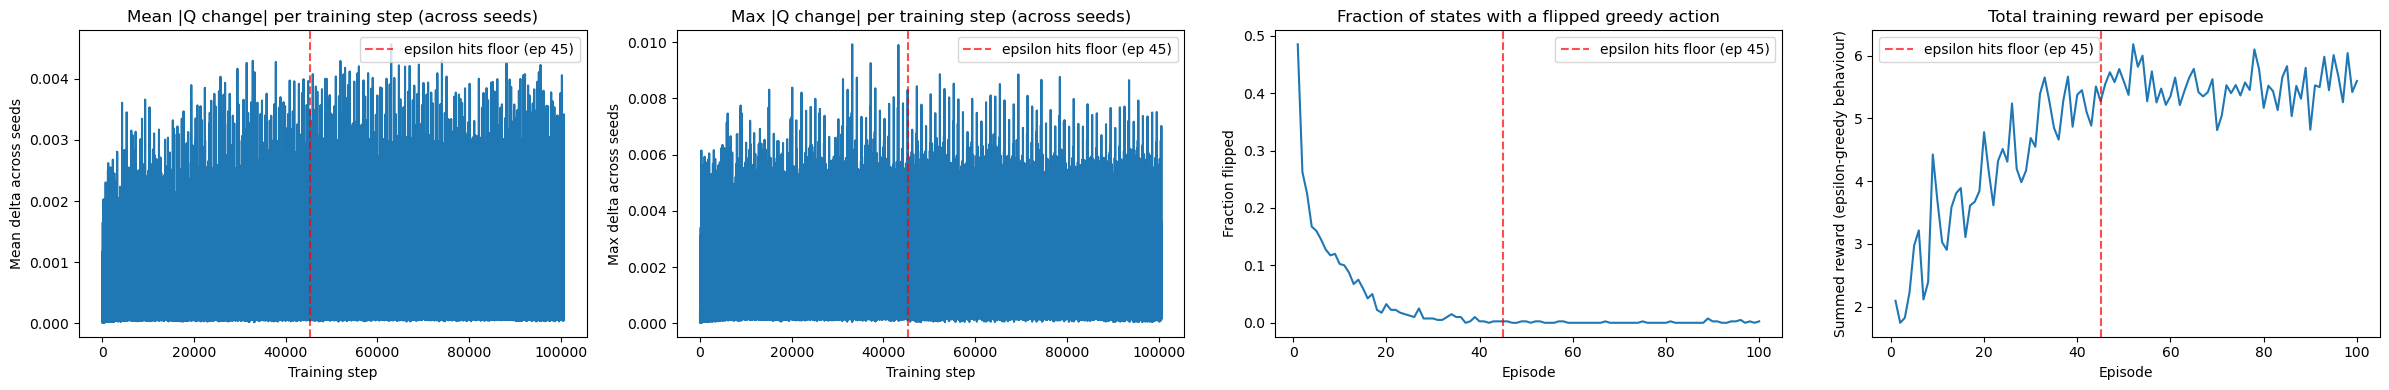

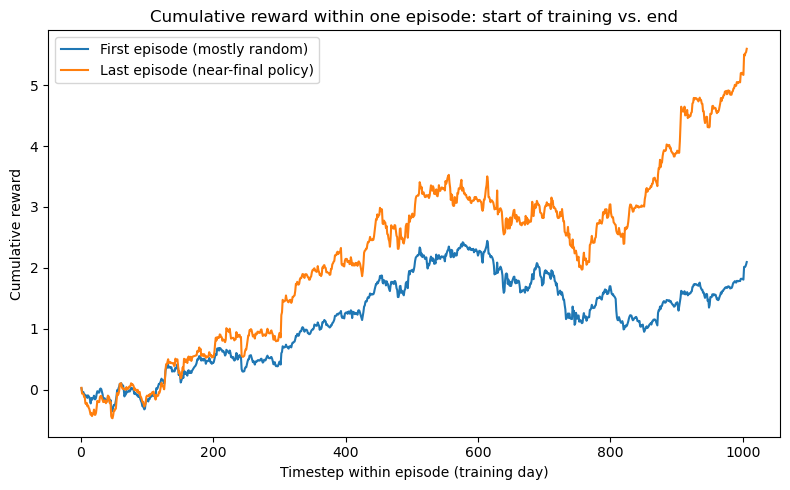

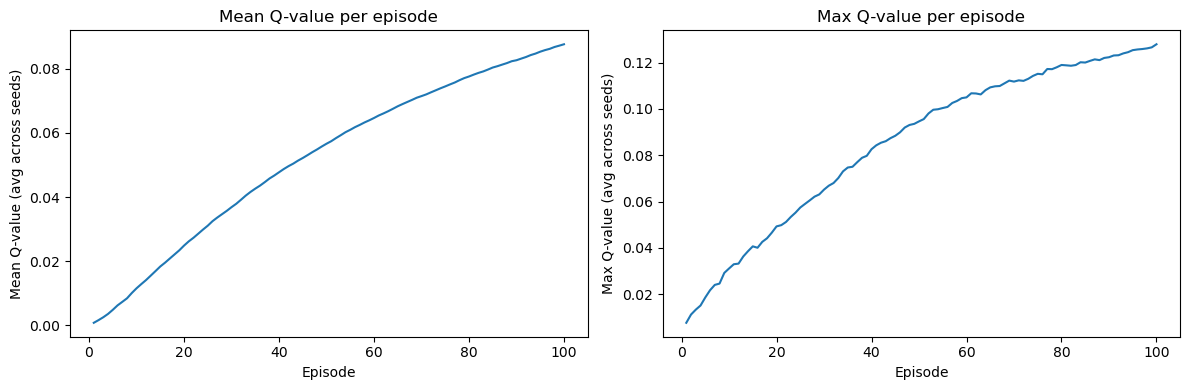

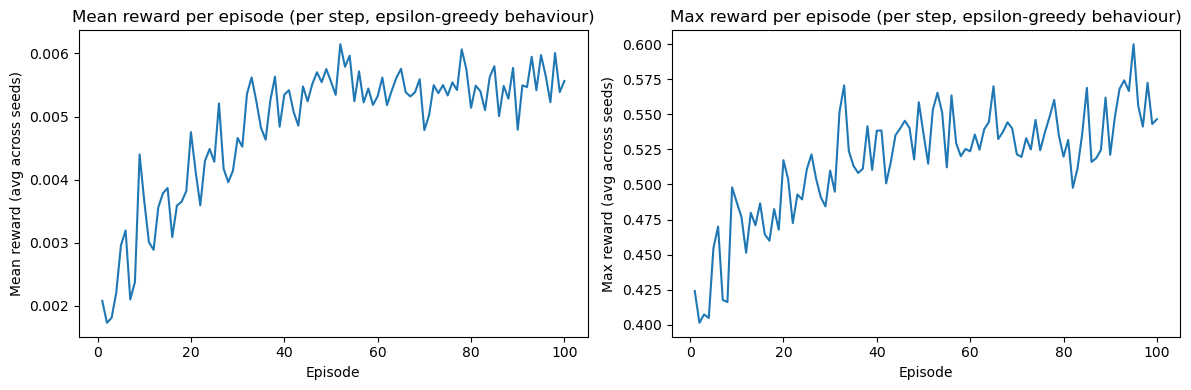


[Policy stability] States checked: 20/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 20 states -- mean: 82.8%  min: 50.0%  max: 100.0%

[State/action summary] 20/20 total states had >= 100 average visits across seeds
 state  avg_visits  majority_action  agreement_pct  mean_Q_majority_action
(4, 0)      6477.9                1          100.0                  0.1201
(2, 0)      6220.2                0           70.0                  0.0930
(9, 0)      6218.9                1           90.0                  0.1038
(8, 0)      6187.4                1           90.0                  0.1063
(7, 0)      6078.1                1           95.0                  0.1081
(6, 0)      6032.2                0           95.0                  0.0953
(3, 0)      6018.4                0           65.0                  0.0917
(1, 0)      5890.5                1           65.0                  0.0918
(5, 0)      5880.5

In [486]:
from diagnostics import run_full_diagnostics

run_full_diagnostics(
    visit_counts=avg_visit_counts,
    delta_history=avg_delta_history_max,
    delta_history_mean=avg_delta_history_mean,
    seed_agents=seed_agents,
    greedy_actions=all_test_actions,
    n_actions=n_actions,
    epsilon_start=epsilon,
    epsilon_decay=epsilon_decay,
    epsilon_floor=epsilon_floor,
    train_results=train_results,
    test_results=test_results,
    policy_flip_history=avg_policy_flip_history,
    episode_reward_history=avg_episode_reward_history,
    first_episode_reward_trace=avg_first_episode_reward_trace,
    last_episode_reward_trace=avg_last_episode_reward_trace,
    q_mean_history=avg_Q_value_mean_history,
    q_max_history=avg_Q_value_max_history,
    reward_mean_history=avg_Reward_mean_history,
    reward_max_history=avg_Reward_max_history,
)

### Quick sanity check (not a diagnostic)

Compares the first and last training episode's per-timestep reward, mean Q, and max Q, side by side. This isn't part of the formal diagnostic checklist -- it's just a fast visual gut-check that the agent is doing *something* sensible (reward not obviously broken, Q not exploding) before trusting the numbers above.

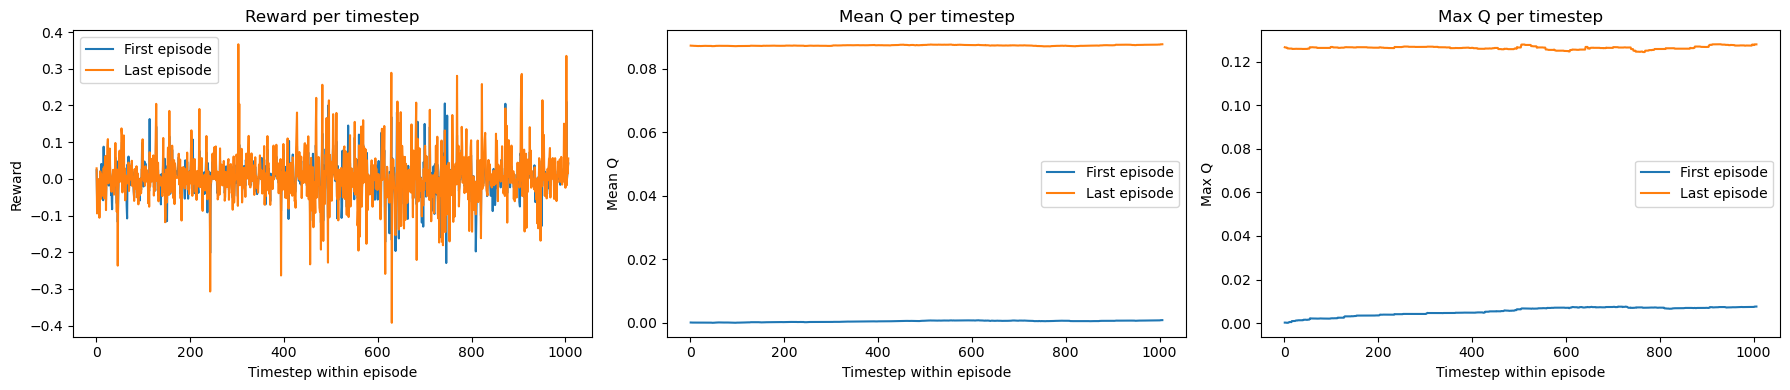

In [487]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
timesteps = range(1, len(avg_first_episode_reward_trace) + 1)

axes[0].plot(timesteps, avg_first_episode_reward_trace, label="First episode")
axes[0].plot(timesteps, avg_last_episode_reward_trace, label="Last episode")
axes[0].set_title("Reward per timestep")
axes[0].set_xlabel("Timestep within episode")
axes[0].set_ylabel("Reward")
axes[0].legend()

axes[1].plot(timesteps, avg_first_episode_q_mean_trace, label="First episode")
axes[1].plot(timesteps, avg_last_episode_q_mean_trace, label="Last episode")
axes[1].set_title("Mean Q per timestep")
axes[1].set_xlabel("Timestep within episode")
axes[1].set_ylabel("Mean Q")
axes[1].legend()

axes[2].plot(timesteps, avg_first_episode_q_max_trace, label="First episode")
axes[2].plot(timesteps, avg_last_episode_q_max_trace, label="Last episode")
axes[2].set_title("Max Q per timestep")
axes[2].set_xlabel("Timestep within episode")
axes[2].set_ylabel("Max Q")
axes[2].legend()

plt.tight_layout()
plt.show()

Tried starting off with high Q values. This didn't work effectivel or the final values were not as good. 

Try to bound the reward by a reward scale parameter which bounds the Q values but still results in rising Q values , rising max Q values per 

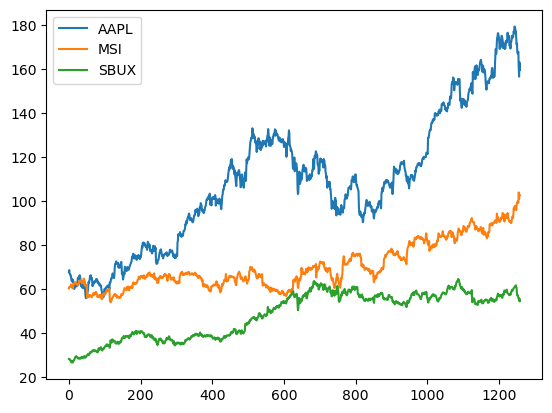

In [172]:
plt.plot(stock_data[:,0], label='AAPL')
plt.plot(stock_data[:,1], label='MSI')
plt.plot(stock_data[:,2], label='SBUX')
plt.legend()

In [141]:
print(avg_Q_mean.mean(axis=0))
print(avg_Q_mean.std(axis=0))

[26.44648058 30.21369589]
[16.97318992 19.31044899]


## Cross-Stock Generalization Test (MSI)

Applies the AAPL-trained Q-learning agents (no further learning, pure greedy rollout via `run_greedy`) to a different stock -- MSI, column 1 of `stock_data` -- on the same test-period date range as AAPL's own `test_raw`, to see how well the learned policy generalizes to a stock it never saw during training. Uses the SAME `bin_edges`/`cash_bin_edges` the agents were trained with, which were derived from AAPL's own return distribution -- so this also tests robustness to that mismatch, not just the learned Q-table by itself.

In [491]:
# column 1 = MSI, same test-period date range as AAPL's test_raw, for a fair comparison
msi_test_raw = stock_data[split:, 1]
N = 20
msi_results = np.zeros(N)
for i, agent in enumerate(seed_agents):
    msi_final, msi_actions = run_greedy(msi_test_raw, agent, n_bins=n_bins, n_cash_bins=n_cash_bins, cash_bin_edges=cash_bin_edges)
    msi_results[i] = msi_final

print(f"AAPL-trained Q-learning agents applied to MSI (test period) -- mean={msi_results.mean():.2f}, std={msi_results.std():.2f}")
print(f"(for comparison) AAPL test period                          -- mean={test_results.mean():.2f}, std={test_results.std():.2f}")

AAPL-trained Q-learning agents applied to MSI (test period) -- mean=11278.32, std=770.89
(for comparison) AAPL test period                          -- mean=11915.01, std=700.69


In [490]:
N = 50
def run_random(raw, n_bins, n_actions, seed):
    rng = np.random.default_rng(seed)
    state = State_basic(raw, initial_cash, n_bins=n_bins, bin_edges=bin_edges,
                         n_cash_bins=n_cash_bins, cash_bin_edges=cash_bin_edges)
    for t in range(len(raw) - 1):
        a = rng.integers(0, n_actions)
        state.reward(a, t)
    final_value = state.portfolio_value(len(raw) - 1)
    return annualization(final_value, len(raw) - 1, initial_cash)

# average over multiple seeds, since a single random run is noisy
random_train_results = np.array([run_random(train_raw, n_bins, n_actions, seed) for seed in range(N)])
random_test_results = np.array([run_random(test_raw, n_bins, n_actions, seed) for seed in range(N)])

print(f"Random trading -- Train: mean={random_train_results.mean():.2f}, std={random_train_results.std():.2f}")
print(f"Random trading -- Test:  mean={random_test_results.mean():.2f}, std={random_test_results.std():.2f}")

Random trading -- Train: mean=10933.27, std=577.83
Random trading -- Test:  mean=11086.31, std=1181.61


In [11]:
def run_buy_and_hold(raw, initial_cash):
    shares = int(initial_cash / raw[0])
    cash = initial_cash - shares * raw[0]
    final_value = cash + shares * raw[-1]
    return annualization(final_value, len(raw) - 1, initial_cash)

buy_hold_train = run_buy_and_hold(train_raw, initial_cash)
buy_hold_test = run_buy_and_hold(test_raw, initial_cash)

print(f"Buy & hold -- Train: {buy_hold_train:.2f}   Test: {buy_hold_test:.2f}")

Buy & hold -- Train: 11799.70   Test: 12071.51


### Extending the above setup to 3 stocks

AAPL, MSI, SBUX are the 3 stocks. 

In [182]:
# --- raw (unscaled) train/test split, matching train_test()'s split point ---
split = int(0.8 * len(stock_data))
train_raw = stock_data[:split]   # column 0 = AAPL, adjust index if using a different stock
test_raw = stock_data[split:]

In [205]:
n = len(train_raw)
returns = train_raw[1:]/train_raw[:(n-1)]
q25 = np.quantile(returns, 0.25, axis=0)
q50 =np.quantile(returns, 0.5, axis=0)
q75 = np.quantile(returns, 0.75, axis=0)
bin_edges = np.transpose(np.array([q25, q50, q75]))
print(bin_edges)
cash_bin_edges = np.array([0.5])

[[0.99291603 1.00051499 1.00915651]
 [0.99473268 1.00046403 1.00634795]
 [0.99351156 1.00071915 1.0083804 ]]


In [212]:
print(len(returns))

1006


In [218]:
equal = np.array([np.digitize(returns[0][i], bin_edges[i]) for i in range(3)])
print(equal)

[3 3 1]


In [221]:
print(equal.shape)

(3,)


In [267]:
import numpy as np

class State_basic:
    # generalized from a single stock to n_stocks (currently 3: AAPL, MSI, SBUX) simultaneously.
    # raw_data is now 2D: (time, n_stocks), e.g. stock_data[:split] rather than stock_data[:split, 0].
    # Cash is a single SHARED pool across all n_stocks (not split into separate per-stock accounts) --
    # the agent can hold any subset of the n_stocks at once, each independently, all-or-nothing per
    # stock (buying a stock always spends whatever cash is still available at that point on just it,
    # selling a stock always liquidates the full position in it) -- same all-or-nothing sizing
    # philosophy as the single-stock version, just applied independently to each stock.
    def __init__(self, raw_data, uninvested_cash, n_bins=10, bin_edges=bin_edges,
                 n_cash_bins=2, cash_bin_edges=cash_bin_edges):
        self.n_stocks = raw_data.shape[1]
        self.shares = np.zeros(self.n_stocks, dtype=int)   # one share count per stock, instead of a single scalar
        self.raw_data = raw_data
        self.uninvested_cash = uninvested_cash
        self.n_bins = n_bins
        self.n_cash_bins = n_cash_bins
        self.bin_edges = bin_edges          # shape (n_stocks, n_bins-1) -- one set of return-bin edges per stock
        self.cash_bin_edges = cash_bin_edges

    def get_real_prices(self, time):
        return self.raw_data[time]   # now a length-n_stocks array, not a scalar

    def get_price_return(self, time):
        # simple gross return per stock: today's price over yesterday's, using only information
        # already known at time t - no look-ahead into price[t+1]
        if time == 0:
            return np.ones(self.n_stocks)  # no prior price on the very first day - treat as "no change"
        return self.raw_data[time] / self.raw_data[time - 1]

    def get_observation(self, time):
        # one return bin per stock, plus a single SHARED cash-fraction bin (same meaning as before:
        # fraction of TOTAL portfolio value currently sitting in uninvested cash) -- observation is
        # now (return_bin_stock0, return_bin_stock1, ..., return_bin_stock{n-1}, cash_bin), used
        # directly as the (n_stocks+1)-dimensional Q-table index
        returns = self.get_price_return(time)
        return_bins = tuple(int(np.digitize(returns[i], self.bin_edges[i])) for i in range(self.n_stocks))
        cash_fraction = self.uninvested_cash / self.portfolio_value(time)
        cash_bin = int(np.digitize(cash_fraction, self.cash_bin_edges))
        return return_bins + (cash_bin,)

    def portfolio_value(self, time):
        return self.uninvested_cash + np.dot(self.shares, self.get_real_prices(time))

    def reward(self, a, time):
        # 8 actions instead of 2: one independent buy/sell-toggle-or-hold decision PER STOCK
        # (n_stocks=3 independent binary sub-decisions -> 2**3 = 8 joint actions), decoded from the
        # bits of a (bit j = stock j's sub-decision: 1 = toggle, 0 = hold). "Toggle" means exactly
        # what "trade" meant in the single-stock version: buy that stock (with whatever cash is
        # still available at that point) if not currently holding it, or sell the full position in
        # it if currently holding it. Since cash is a single pool shared across all n_stocks, buys
        # are resolved in a fixed stock order (0, 1, 2, ...) within a single timestep -- an earlier
        # stock in that order gets first claim on the cash available that step, so which stocks
        # actually get bought (and how much) when several are toggled at once, and cash is tight,
        # depends on this order. Selling isn't affected by this, since it only ever adds cash back.
        prices_now = self.get_real_prices(time)
        portfolio_before = self.uninvested_cash + np.dot(self.shares, prices_now)

        for j in range(self.n_stocks):
            toggle = (a >> j) & 1   # bit j of a: this stock's sub-decision
            if toggle:
                if self.shares[j] == 0:
                    shares_bought = int(self.uninvested_cash / prices_now[j])
                    self.uninvested_cash -= prices_now[j] * shares_bought
                    self.shares[j] += shares_bought
                else:
                    self.uninvested_cash += prices_now[j] * self.shares[j]
                    self.shares[j] = 0
            # toggle == 0: hold this stock, no change

        price_next = self.get_real_prices(time + 1)
        portfolio_after = self.uninvested_cash + np.dot(self.shares, price_next)
        return portfolio_after - portfolio_before

In [268]:
class Agent_basic:
    # Q is now indexed by (return_bin_stock0, ..., return_bin_stock{n_stocks-1}, cash_bin, action) --
    # n_stocks+2 dimensions total instead of the single-stock version's 3 (return_bin, cash_bin, action).
    # n_stocks must match the n_stocks actually used to build State_basic's observations (3 here).
    def __init__(self, n_bins, n_cash_bins, n_stocks=3, n_actions=8, eta=0.1, gamma=0.95):
        q_shape = (n_bins,) * n_stocks + (n_cash_bins, n_actions)
        self.Q = np.zeros(q_shape)
        self.visit_counts = np.zeros(q_shape, dtype=int)  # for the coverage diagnostic
        self.eta = eta       # step size, alpha
        self.gamma = gamma

    def select_action(self, s):
        return np.argmax(self.Q[s])   # s is now a (return_bin_stock0, ..., return_bin_stock{n_stocks-1}, cash_bin) tuple

    def update(self, s, s_next, a, r):
        # standard Q-learning: bootstraps off the MAX over next-state actions (off-policy)
        target = r + self.gamma * np.max(self.Q[s_next])
        self.Q[s][a] = self.Q[s][a] + self.eta * (target - self.Q[s][a])
        self.visit_counts[s][a] += 1

    def update_expected_sarsa(self, s, s_next, a, r, epsilon):
        # Expected SARSA: bootstraps off the EXPECTED value of the next state under the
        # epsilon-greedy behaviour policy, instead of the max - same update rule shape as
        # Q-learning, just a different (lower-variance, on-policy) target
        q_next = self.Q[s_next]
        n_actions = len(q_next)
        greedy_action = np.argmax(q_next)
        action_probs = np.full(n_actions, epsilon / n_actions)
        action_probs[greedy_action] += (1 - epsilon)
        expected_q_next = np.sum(action_probs * q_next)
        target = r + self.gamma * expected_q_next
        self.Q[s][a] = self.Q[s][a] + self.eta * (target - self.Q[s][a])
        self.visit_counts[s][a] += 1

In [297]:
# hyperparameters for the basic single-stock Q-learning agent
# (previously left over from a deleted cell's kernel state - now defined explicitly so this notebook reruns standalone)
n_bins = 4
episodes = 50
n_actions = 8  # 2**n_stocks -- one independent toggle/hold decision per stock (3 stocks) - see State_basic.reward
eta = 0.01
gamma = 0.9
epsilon = 1.0
epsilon_decay = 0.95
epsilon_floor = 0.1
initial_cash = 10000
bin_edges = bin_edges  # daily price-return bins (price[t]/price[t-1]): 0.9-1.1 = -10% to +10%
n_cash_bins = 2
cash_bin_edges = cash_bin_edges
N = 20  # cash as a fraction of the CURRENT portfolio value: always exactly ~0 (invested)
                          # or exactly 1.0 (in cash) given the all-or-nothing buy/sell design, so this is
                          # a genuine binary position flag - a single edge at the midpoint (0.5) splits it

In [ ]:
def run_greedy(raw, agent, n_bins, n_cash_bins=2, cash_bin_edges=cash_bin_edges):
    state = State_basic(raw, uninvested_cash=initial_cash, n_bins=n_bins, bin_edges=bin_edges,
                         n_cash_bins=n_cash_bins, cash_bin_edges=cash_bin_edges)
    actions_taken = []
    for t in range(len(raw) - 1):
        s = state.get_observation(t)
        a = agent.select_action(s)
        actions_taken.append(a)
        state.reward(a, t)
    final_value = state.portfolio_value(len(raw) - 1)
    annualized_value = annualization(final_value, len(raw) - 1, initial_cash)
    return annualized_value, actions_taken


def train_and_evaluate_greedy(seed, train_raw, test_raw, episodes=10, n_actions=8, eta=0.1, gamma=0.95,
                        epsilon_start=1.0, epsilon_decay=0.995, epsilon_floor=0.0, bin_edges=bin_edges,
                        cash_bin_edges=cash_bin_edges, n_bins=n_bins, n_cash_bins=n_cash_bins):
    np.random.seed(seed)

    n_stocks = train_raw.shape[1]  # inferred from the data itself, so it can't drift out of sync with n_actions
    agent = Agent_basic(n_bins=n_bins, n_cash_bins=n_cash_bins, n_stocks=n_stocks, n_actions=n_actions, eta=eta, gamma=gamma)
    train_size = len(train_raw)
    epsilon = epsilon_start
    # one entry PER TRAINING STEP now (not per episode) -- the magnitude of that single
    # (state, action) cell's update, |Q_new[s][a] - Q_old[s][a]|. Every episode's steps
    # get appended back-to-back in training order, so this list ends up length
    # episodes * (train_size - 1) by the end of the whole run. "Max"/"mean" ACROSS
    # SEEDS of this same per-step value is computed later, in the main loop below.
    step_delta_history = []
    policy_flip_history = []  # fraction of states whose greedy action (argmax Q) changed since the previous episode
    episode_reward_history = []  # total (epsilon-greedy) reward earned during each whole training episode
    Q_mean = []
    # actual Q-VALUE magnitude (not its change) at the end of each episode -- checks whether Q is
    # settling into a stable range or drifting off unboundedly, which delta-based checks alone
    # wouldn't catch (small consistently-one-directional updates can still add up to steady growth)
    Q_value_mean_history = []
    Q_value_max_history = []
    # raw per-step REWARD magnitude per episode -- reward = portfolio_after - portfolio_before is
    # the direct environment signal, not a Q estimate, so this is an independent sanity check on
    # top of the Q-value trend above (mean is per-STEP within the episode, not the episode's total
    # -- that's episode_reward_history above; max is the single biggest reward that episode)
    Reward_mean_history = []
    Reward_max_history = []
    first_episode_reward_trace = None  # per-timestep reward within episode 0 (near-random behaviour)
    last_episode_reward_trace = None   # per-timestep reward within the final episode (near-final policy)

    for ep in range(episodes):
        Q_before = agent.Q.copy()  # still needed for policy_flip_history, an episode-level (not step-level) comparison
        state = State_basic(train_raw, uninvested_cash=initial_cash, n_bins=n_bins, bin_edges=bin_edges,
                             n_cash_bins=n_cash_bins, cash_bin_edges=cash_bin_edges)
        # only the first and last episode's per-timestep rewards are kept in full (for
        # plot_episode_trajectory) -- every other episode just needs its total, so we avoid
        # paying the memory cost of storing a long trace for all `episodes` passes
        track_trace = (ep == 0) or (ep == episodes - 1)
        reward_trace = [] if track_trace else None
        episode_reward_total = 0.0
        episode_reward_max = -np.inf
        for t in range(train_size - 1):
            s = state.get_observation(t)
            if np.random.rand() < epsilon:
                a = np.random.randint(agent.Q.shape[-1])   # pulls n_actions from the agent, not a hardcoded 3
            else:
                a = agent.select_action(s)
            r = state.reward(a, t)
            episode_reward_total += r
            episode_reward_max = max(episode_reward_max, r)
            if track_trace:
                reward_trace.append(r)
            s_next = state.get_observation(t + 1)
            q_before_step = agent.Q[s][a]   # only this ONE cell is about to change
            agent.update(s, s_next, a, r)
            step_delta_history.append(abs(agent.Q[s][a] - q_before_step))
        epsilon = max(epsilon * epsilon_decay, epsilon_floor)  # decay stops here, never goes below the floor
        # policy convergence, not value convergence: does the greedy action at each state actually
        # change episode to episode, regardless of how much the underlying Q magnitudes still move
        policy_before = np.argmax(Q_before, axis=-1)
        policy_after = np.argmax(agent.Q, axis=-1)
        policy_flip_history.append(np.mean(policy_before != policy_after))
        # mean Q per action, collapsed over every STATE dimension (however many there are) -- not
        # hardcoded to the old single-stock (n_bins, n_cash_bins, n_actions) 3D shape any more
        Q_mean.append(agent.Q.mean(axis=tuple(range(agent.Q.ndim - 1))))
        Q_value_mean_history.append(agent.Q.mean())
        Q_value_max_history.append(agent.Q.max())
        episode_reward_history.append(episode_reward_total)
        Reward_mean_history.append(episode_reward_total / (train_size - 1))
        Reward_max_history.append(episode_reward_max)
        if ep == 0:
            first_episode_reward_trace = reward_trace
        if ep == episodes - 1:
            last_episode_reward_trace = reward_trace

    train_final, train_actions = run_greedy(train_raw, agent, n_bins=n_bins, n_cash_bins=n_cash_bins)
    test_final, test_actions = run_greedy(test_raw, agent, n_bins=n_bins, n_cash_bins=n_cash_bins)

    return (agent, train_final, test_final, step_delta_history, train_actions, test_actions,
            Q_mean, policy_flip_history, episode_reward_history, first_episode_reward_trace, last_episode_reward_trace,
            Q_value_mean_history, Q_value_max_history, Reward_mean_history, Reward_max_history)

In [ ]:
train_results = np.zeros(N)
test_results = np.zeros(N)
seed_agents = []             # every seed's trained agent, for coverage / policy-stability diagnostics
all_step_delta_history = []  # every seed's per-training-step delta curve -- mean/max ACROSS SEEDS computed below
all_test_actions = []        # every seed's greedy test rollout, for the action-distribution diagnostic
all_policy_flip_history = []  # every seed's per-episode action-flip fraction, averaged for the convergence diagnostic
all_episode_reward_history = []      # every seed's per-episode total training reward, averaged for the reward curve
all_first_episode_reward_trace = []  # every seed's episode-0 per-timestep reward trace, averaged for the within-episode plot
all_last_episode_reward_trace = []   # every seed's final-episode per-timestep reward trace, averaged for the within-episode plot
all_Q_value_mean_history = []  # every seed's per-episode mean-Q-value curve, averaged for the Q-value-magnitude plot
all_Q_value_max_history = []   # every seed's per-episode max-Q-value curve, averaged for the Q-value-magnitude plot
all_Reward_mean_history = []   # every seed's per-episode mean-reward-per-step curve, averaged for the reward-magnitude plot
all_Reward_max_history = []    # every seed's per-episode max-reward curve, averaged for the reward-magnitude plot
Q_mean_values = []
for seed in range(N):
    (agent, train_final, test_final, step_delta_history, train_actions, test_actions,
     Q_mean, policy_flip_history, episode_reward_history, first_episode_reward_trace, last_episode_reward_trace,
     Q_value_mean_history, Q_value_max_history, Reward_mean_history, Reward_max_history) = train_and_evaluate_greedy(
        seed, train_raw, test_raw, episodes=episodes, n_bins=n_bins, n_actions=n_actions, eta=eta, gamma=gamma,
        epsilon_start=epsilon, epsilon_decay=epsilon_decay, epsilon_floor = epsilon_floor, bin_edges=bin_edges,
        n_cash_bins=n_cash_bins, cash_bin_edges=cash_bin_edges)
    train_results[seed] = train_final
    test_results[seed] = test_final
    seed_agents.append(agent)
    all_step_delta_history.append(step_delta_history)
    all_test_actions.append(test_actions)
    all_policy_flip_history.append(policy_flip_history)
    all_episode_reward_history.append(episode_reward_history)
    all_first_episode_reward_trace.append(first_episode_reward_trace)
    all_last_episode_reward_trace.append(last_episode_reward_trace)
    all_Q_value_mean_history.append(Q_value_mean_history)
    all_Q_value_max_history.append(Q_value_max_history)
    all_Reward_mean_history.append(Reward_mean_history)
    all_Reward_max_history.append(Reward_max_history)
    Q_mean_values.append(Q_mean)

# same variable names as before (avg_delta_history_max/mean) so nothing downstream (the
# diagnostics call below) needs to change -- just what they now mean: per TRAINING STEP,
# aggregated across seeds, instead of per episode, aggregated across the whole Q-table
avg_delta_history_mean = np.mean(all_step_delta_history, axis=0)  # mean across seeds, per training step
avg_delta_history_max = np.max(all_step_delta_history, axis=0)    # max across seeds, per training step
avg_policy_flip_history = np.mean(all_policy_flip_history, axis=0)
avg_episode_reward_history = np.mean(all_episode_reward_history, axis=0)
avg_first_episode_reward_trace = np.mean(all_first_episode_reward_trace, axis=0)
avg_last_episode_reward_trace = np.mean(all_last_episode_reward_trace, axis=0)
avg_Q_value_mean_history = np.mean(all_Q_value_mean_history, axis=0)  # mean across seeds, per episode
avg_Q_value_max_history = np.mean(all_Q_value_max_history, axis=0)    # mean across seeds, per episode
avg_Reward_mean_history = np.mean(all_Reward_mean_history, axis=0)    # mean across seeds, per episode
avg_Reward_max_history = np.mean(all_Reward_max_history, axis=0)      # mean across seeds, per episode
avg_Q_mean = np.mean(Q_mean_values, axis=0)
avg_visit_counts = np.mean([agent.visit_counts for agent in seed_agents], axis=0)

print(f"Episodes = {episodes}")
print(f"Q-learning (greedy) -- Train: mean={train_results.mean():.2f}, std={train_results.std():.2f}")
print(f"Q-learning (greedy) -- Test:  mean={test_results.mean():.2f}, std={test_results.std():.2f}")

In [ ]:
from diagnostics import run_full_diagnostics

run_full_diagnostics(
    visit_counts=avg_visit_counts,
    delta_history=avg_delta_history_max,
    delta_history_mean=avg_delta_history_mean,
    seed_agents=seed_agents,
    greedy_actions=all_test_actions,
    n_actions=n_actions,
    epsilon_start=epsilon,
    epsilon_decay=epsilon_decay,
    epsilon_floor=epsilon_floor,
    train_results=train_results,
    test_results=test_results,
    policy_flip_history=avg_policy_flip_history,
    episode_reward_history=avg_episode_reward_history,
    first_episode_reward_trace=avg_first_episode_reward_trace,
    last_episode_reward_trace=avg_last_episode_reward_trace,
    q_mean_history=avg_Q_value_mean_history,
    q_max_history=avg_Q_value_max_history,
    reward_mean_history=avg_Reward_mean_history,
    reward_max_history=avg_Reward_max_history,
)

## Hyperparameter Tuning

`eta` and `gamma` are the two hyperparameters actually being searched here (`n_cash_bins`/`cash_bin_range` are fixed since cash discretization isn't being changed, and `n_bins`/`bin_range` are fixed for now too).

To pick them without leaking information from the true held-out `test_raw`, the *training* data itself is split again 80/20: an inner slice to actually train candidates on, and an inner validation slice to score them on. `test_raw` is never touched during this search - it's only used afterward, in each algorithm's own section above, once real hyperparameters are chosen.

In [13]:
# further split train_raw into an inner train/validation split, so hyperparameters
# are chosen without the search ever seeing the true held-out test_raw
hp_split = int(0.8 * len(train_raw))
hp_train_raw = train_raw[:hp_split]
hp_val_raw = train_raw[hp_split:]

print(f"Hyperparameter tuning -- inner train: {len(hp_train_raw)} days, inner validation: {len(hp_val_raw)} days")

Hyperparameter tuning -- inner train: 805 days, inner validation: 202 days


In [30]:
# hyperparameters for the basic single-stock Q-learning agent
# (previously left over from a deleted cell's kernel state - now defined explicitly so this notebook reruns standalone)
n_bins = 10
episodes = 100
n_actions = 3
eta = 0.1
gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.95
epsilon_floor = 0.1
initial_cash = 10000
bin_range = (0.9, 1.1)  # daily price-return bins (price[t]/price[t-1]): 0.9-1.1 = -10% to +10%
n_cash_bins = 2
cash_bin_range = (0, 1)  # cash as a fraction of the CURRENT portfolio value: always exactly ~0 (invested)
                          # or exactly 1.0 (in cash) given the all-or-nothing buy/sell design, so this is
                          # a genuine binary position flag - a single edge at the midpoint (0.5) splits it

In [ ]:
def grid_search_hyperparameters(train_fn, eta_grid, gamma_grid, N=20, episodes=episodes,
                                  epsilon_start=epsilon, epsilon_decay=epsilon_decay, epsilon_floor=epsilon_floor,
                                  run_diagnostics=False):
    """Train N seeds per (eta, gamma) combination on hp_train_raw, score them on
    hp_val_raw (a held-out slice of the TRAINING data, not the true test set), and
    return a table of validation mean/std for every combination, best first.
    train_fn: one of train_and_evaluate_greedy / _expected_sarsa / _double_q --
    they all share the same (seed, train_raw, test_raw, ...) calling convention.
    episodes/epsilon_start/epsilon_decay/epsilon_floor default to the notebook's
    global values but can be overridden here without touching those globals (e.g.
    for a one-off test with a faster epsilon decay, a floor so epsilon never fully
    vanishes, or a different episode count).
    run_diagnostics: if True, also runs the full diagnostic checklist for every
    (eta, gamma) combination as it's evaluated - not just the eventual winner.
    Off by default since it multiplies the printed output by len(eta_grid)*len(gamma_grid).
    """
    rows = []
    for eta_try in eta_grid:
        for gamma_try in gamma_grid:
            val_scores = np.zeros(N)
            seed_agents = []
            all_delta_history_max = []
            all_delta_history_mean = []
            all_val_actions = []
            for seed in range(N):
                agent, train_final, val_final, delta_history_max, delta_history_mean, _, val_actions = train_fn(
                    seed, hp_train_raw, hp_val_raw, episodes=episodes,
                    n_bins=n_bins, n_actions=n_actions, eta=eta_try, gamma=gamma_try,
                    epsilon_start=epsilon_start, epsilon_decay=epsilon_decay, epsilon_floor=epsilon_floor,
                    bin_range=bin_range, n_cash_bins=n_cash_bins, cash_bin_range=cash_bin_range)
                val_scores[seed] = val_final
                seed_agents.append(agent)
                all_delta_history_max.append(delta_history_max)
                all_delta_history_mean.append(delta_history_mean)
                all_val_actions.append(val_actions)
            rows.append({"eta": eta_try, "gamma": gamma_try,
                         "val_mean": val_scores.mean(), "val_std": val_scores.std()})

            if run_diagnostics:
                print(f"\n--- eta={eta_try}, gamma={gamma_try} ---")
                run_full_diagnostics(
                    visit_counts=np.mean([a.visit_counts for a in seed_agents], axis=0),
                    delta_history=np.mean(all_delta_history_max, axis=0),
                    delta_history_mean=np.mean(all_delta_history_mean, axis=0),
                    seed_agents=seed_agents,
                    greedy_actions=all_val_actions,
                    n_actions=n_actions,
                    epsilon_start=epsilon_start,
                    epsilon_decay=epsilon_decay,
                    epsilon_floor=epsilon_floor,
                    train_results = train_results,
                    test_results = val_scores
                )
    return pd.DataFrame(rows).sort_values("val_mean", ascending=False).reset_index(drop=True)


eta_grid = [0.0005, 0.001, 0.005]
gamma_grid = [0.9, 0.95, 0.99]


--- eta=0.0005, gamma=0.9 ---
DIAGNOSTIC CHECKLIST
[Coverage] Unvisited (state, action) pairs: 12 / 60 (20.0%)
  Unvisited pairs (state..., action): [(np.int64(0), np.int64(0), np.int64(0)), (np.int64(0), np.int64(0), np.int64(1)), (np.int64(0), np.int64(0), np.int64(2)), (np.int64(0), np.int64(1), np.int64(0)), (np.int64(0), np.int64(1), np.int64(1)), (np.int64(0), np.int64(1), np.int64(2)), (np.int64(9), np.int64(0), np.int64(0)), (np.int64(9), np.int64(0), np.int64(1)), (np.int64(9), np.int64(0), np.int64(2)), (np.int64(9), np.int64(1), np.int64(0))] ...

[Convergence] Final delta: 0.936438 (NOT YET CONVERGED, consider more episodes)


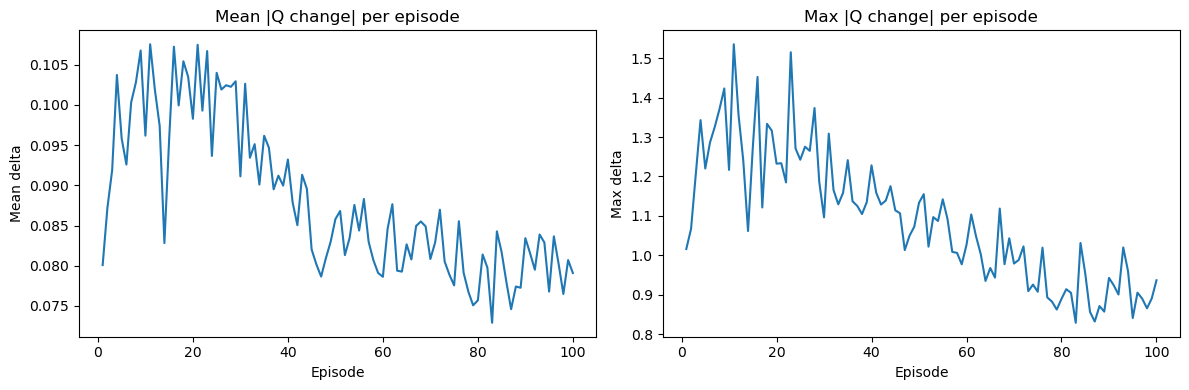


[Policy stability] States checked: 12/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 12 states -- mean: 74.6%  min: 50.0%  max: 100.0%

[Action distribution] Mean action fractions across 20 seeds (one number per action, averaged over all seeds): 38.8%, 30.8%, 30.4%
[Action distribution] Per-action spread across seeds -- min: 23.4%, 2.5%, 1.0%  max: 93.5%, 46.8%, 53.2%
[Seed degeneracy] Seeds with one action >= 95% of their own decisions: 0/20


--- eta=0.0005, gamma=0.95 ---
DIAGNOSTIC CHECKLIST
[Coverage] Unvisited (state, action) pairs: 12 / 60 (20.0%)
  Unvisited pairs (state..., action): [(np.int64(0), np.int64(0), np.int64(0)), (np.int64(0), np.int64(0), np.int64(1)), (np.int64(0), np.int64(0), np.int64(2)), (np.int64(0), np.int64(1), np.int64(0)), (np.int64(0), np.int64(1), np.int64(1)), (np.int64(0), np.int64(1), np.int64(2)), (np.int64(9), np.int64(0), np.int64(0)), (np.int64(9), np.int64(

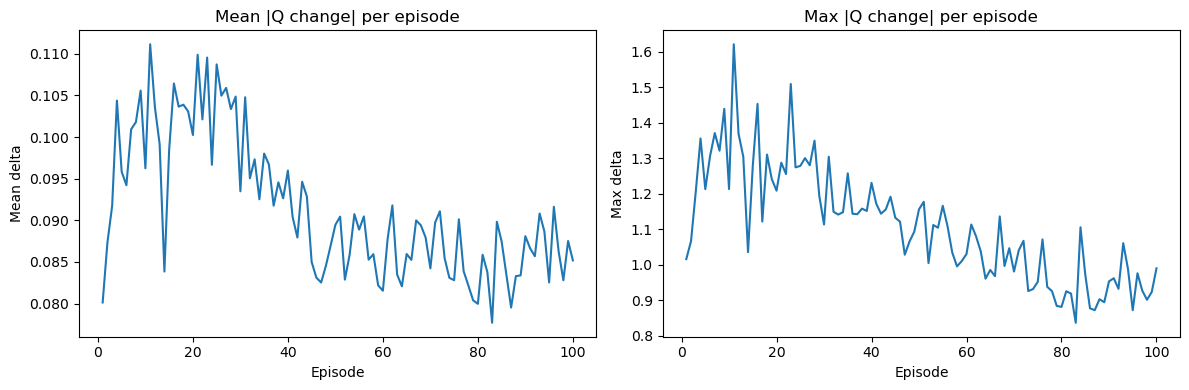


[Policy stability] States checked: 12/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 12 states -- mean: 73.3%  min: 45.0%  max: 100.0%

[Action distribution] Mean action fractions across 20 seeds (one number per action, averaged over all seeds): 39.8%, 29.7%, 30.5%
[Action distribution] Per-action spread across seeds -- min: 23.4%, 2.5%, 1.0%  max: 93.5%, 46.8%, 53.2%
[Seed degeneracy] Seeds with one action >= 95% of their own decisions: 0/20


--- eta=0.0005, gamma=0.99 ---
DIAGNOSTIC CHECKLIST
[Coverage] Unvisited (state, action) pairs: 12 / 60 (20.0%)
  Unvisited pairs (state..., action): [(np.int64(0), np.int64(0), np.int64(0)), (np.int64(0), np.int64(0), np.int64(1)), (np.int64(0), np.int64(0), np.int64(2)), (np.int64(0), np.int64(1), np.int64(0)), (np.int64(0), np.int64(1), np.int64(1)), (np.int64(0), np.int64(1), np.int64(2)), (np.int64(9), np.int64(0), np.int64(0)), (np.int64(9), np.int64(

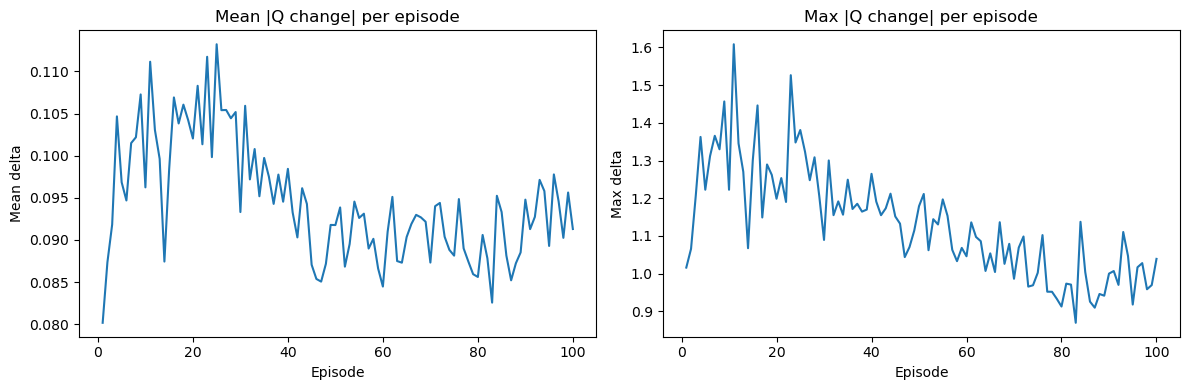


[Policy stability] States checked: 12/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 12 states -- mean: 72.1%  min: 45.0%  max: 100.0%

[Action distribution] Mean action fractions across 20 seeds (one number per action, averaged over all seeds): 40.9%, 28.5%, 30.6%
[Action distribution] Per-action spread across seeds -- min: 23.4%, 2.0%, 1.0%  max: 93.5%, 46.8%, 53.2%
[Seed degeneracy] Seeds with one action >= 95% of their own decisions: 0/20


--- eta=0.001, gamma=0.9 ---
DIAGNOSTIC CHECKLIST
[Coverage] Unvisited (state, action) pairs: 12 / 60 (20.0%)
  Unvisited pairs (state..., action): [(np.int64(0), np.int64(0), np.int64(0)), (np.int64(0), np.int64(0), np.int64(1)), (np.int64(0), np.int64(0), np.int64(2)), (np.int64(0), np.int64(1), np.int64(0)), (np.int64(0), np.int64(1), np.int64(1)), (np.int64(0), np.int64(1), np.int64(2)), (np.int64(9), np.int64(0), np.int64(0)), (np.int64(9), np.int64(0)

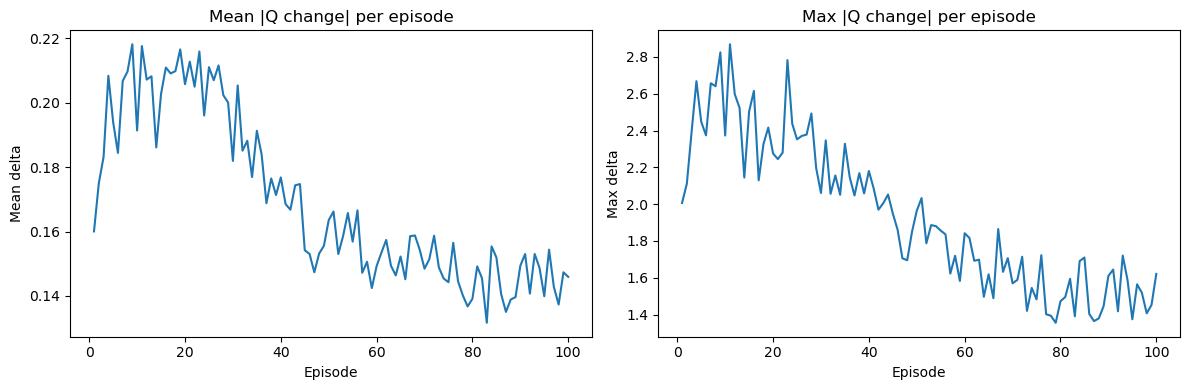


[Policy stability] States checked: 12/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 12 states -- mean: 73.3%  min: 50.0%  max: 100.0%

[Action distribution] Mean action fractions across 20 seeds (one number per action, averaged over all seeds): 38.4%, 29.6%, 32.0%
[Action distribution] Per-action spread across seeds -- min: 23.4%, 2.0%, 1.5%  max: 96.0%, 46.8%, 53.2%
[Seed degeneracy] Seeds with one action >= 95% of their own decisions: 1/20
  Which action dominates those seeds (count per action index): [1, 0, 0]


--- eta=0.001, gamma=0.95 ---
DIAGNOSTIC CHECKLIST
[Coverage] Unvisited (state, action) pairs: 12 / 60 (20.0%)
  Unvisited pairs (state..., action): [(np.int64(0), np.int64(0), np.int64(0)), (np.int64(0), np.int64(0), np.int64(1)), (np.int64(0), np.int64(0), np.int64(2)), (np.int64(0), np.int64(1), np.int64(0)), (np.int64(0), np.int64(1), np.int64(1)), (np.int64(0), np.int64(1), np.int

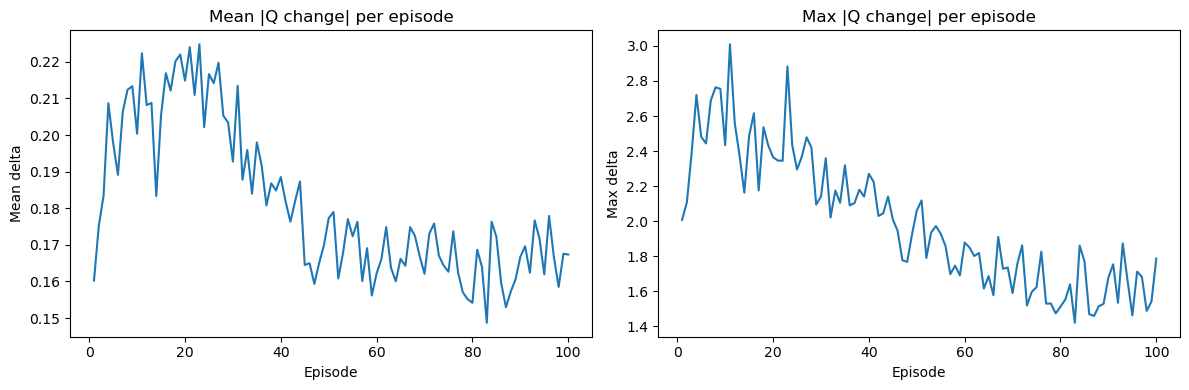


[Policy stability] States checked: 12/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 12 states -- mean: 69.6%  min: 40.0%  max: 100.0%

[Action distribution] Mean action fractions across 20 seeds (one number per action, averaged over all seeds): 43.6%, 28.4%, 28.0%
[Action distribution] Per-action spread across seeds -- min: 23.4%, 2.0%, 1.0%  max: 96.0%, 46.8%, 53.2%
[Seed degeneracy] Seeds with one action >= 95% of their own decisions: 1/20
  Which action dominates those seeds (count per action index): [1, 0, 0]


--- eta=0.001, gamma=0.99 ---
DIAGNOSTIC CHECKLIST
[Coverage] Unvisited (state, action) pairs: 12 / 60 (20.0%)
  Unvisited pairs (state..., action): [(np.int64(0), np.int64(0), np.int64(0)), (np.int64(0), np.int64(0), np.int64(1)), (np.int64(0), np.int64(0), np.int64(2)), (np.int64(0), np.int64(1), np.int64(0)), (np.int64(0), np.int64(1), np.int64(1)), (np.int64(0), np.int64(1), np.int

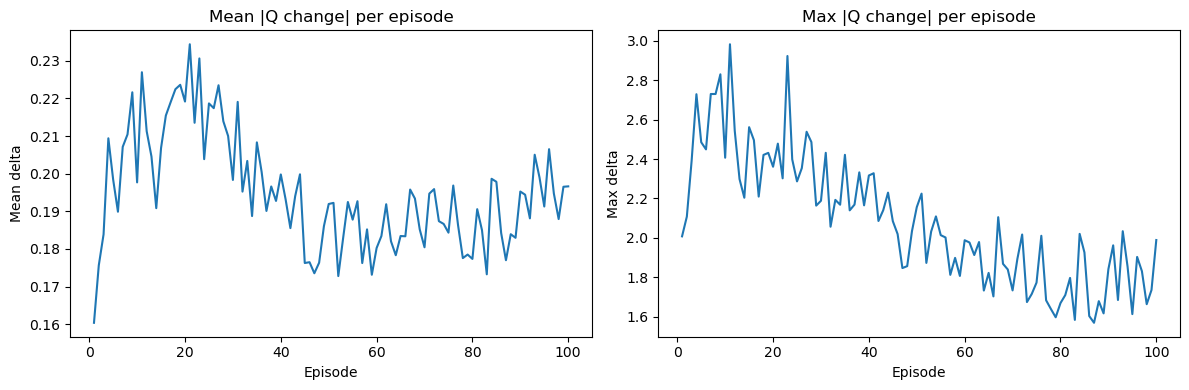


[Policy stability] States checked: 12/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 12 states -- mean: 70.4%  min: 40.0%  max: 100.0%

[Action distribution] Mean action fractions across 20 seeds (one number per action, averaged over all seeds): 40.8%, 28.5%, 30.7%
[Action distribution] Per-action spread across seeds -- min: 23.4%, 2.0%, 1.0%  max: 96.0%, 46.8%, 53.2%
[Seed degeneracy] Seeds with one action >= 95% of their own decisions: 1/20
  Which action dominates those seeds (count per action index): [1, 0, 0]


--- eta=0.005, gamma=0.9 ---
DIAGNOSTIC CHECKLIST
[Coverage] Unvisited (state, action) pairs: 12 / 60 (20.0%)
  Unvisited pairs (state..., action): [(np.int64(0), np.int64(0), np.int64(0)), (np.int64(0), np.int64(0), np.int64(1)), (np.int64(0), np.int64(0), np.int64(2)), (np.int64(0), np.int64(1), np.int64(0)), (np.int64(0), np.int64(1), np.int64(1)), (np.int64(0), np.int64(1), np.int6

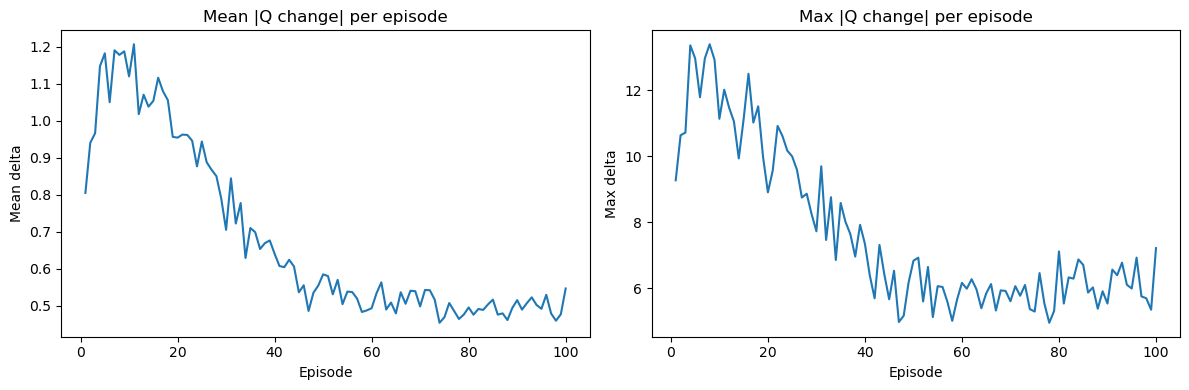


[Policy stability] States checked: 12/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 12 states -- mean: 75.0%  min: 35.0%  max: 100.0%

[Action distribution] Mean action fractions across 20 seeds (one number per action, averaged over all seeds): 35.5%, 44.6%, 19.9%
[Action distribution] Per-action spread across seeds -- min: 23.9%, 23.9%, 1.0%  max: 51.2%, 63.7%, 30.8%
[Seed degeneracy] Seeds with one action >= 95% of their own decisions: 0/20


--- eta=0.005, gamma=0.95 ---
DIAGNOSTIC CHECKLIST
[Coverage] Unvisited (state, action) pairs: 12 / 60 (20.0%)
  Unvisited pairs (state..., action): [(np.int64(0), np.int64(0), np.int64(0)), (np.int64(0), np.int64(0), np.int64(1)), (np.int64(0), np.int64(0), np.int64(2)), (np.int64(0), np.int64(1), np.int64(0)), (np.int64(0), np.int64(1), np.int64(1)), (np.int64(0), np.int64(1), np.int64(2)), (np.int64(9), np.int64(0), np.int64(0)), (np.int64(9), np.int64(

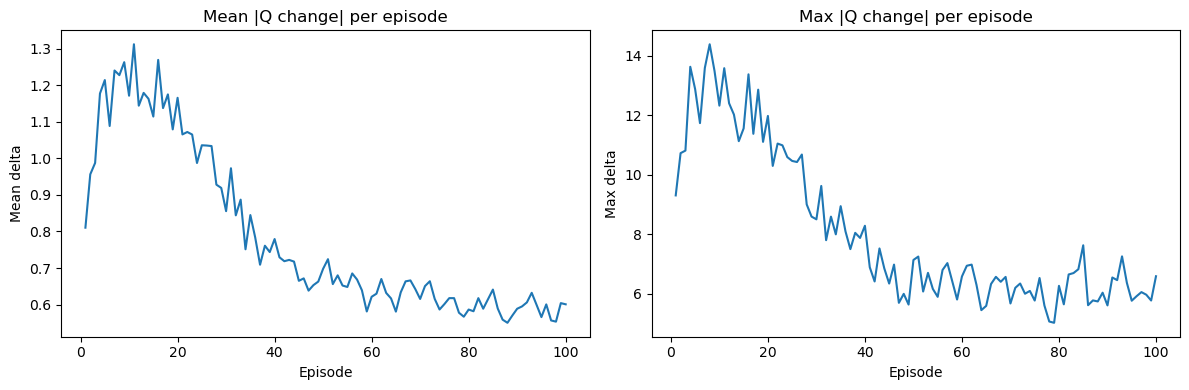


[Policy stability] States checked: 12/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 12 states -- mean: 69.6%  min: 40.0%  max: 100.0%

[Action distribution] Mean action fractions across 20 seeds (one number per action, averaged over all seeds): 44.4%, 36.8%, 18.8%
[Action distribution] Per-action spread across seeds -- min: 24.9%, 2.0%, 0.5%  max: 94.5%, 63.7%, 49.8%
[Seed degeneracy] Seeds with one action >= 95% of their own decisions: 0/20


--- eta=0.005, gamma=0.99 ---
DIAGNOSTIC CHECKLIST
[Coverage] Unvisited (state, action) pairs: 12 / 60 (20.0%)
  Unvisited pairs (state..., action): [(np.int64(0), np.int64(0), np.int64(0)), (np.int64(0), np.int64(0), np.int64(1)), (np.int64(0), np.int64(0), np.int64(2)), (np.int64(0), np.int64(1), np.int64(0)), (np.int64(0), np.int64(1), np.int64(1)), (np.int64(0), np.int64(1), np.int64(2)), (np.int64(9), np.int64(0), np.int64(0)), (np.int64(9), np.int64(0

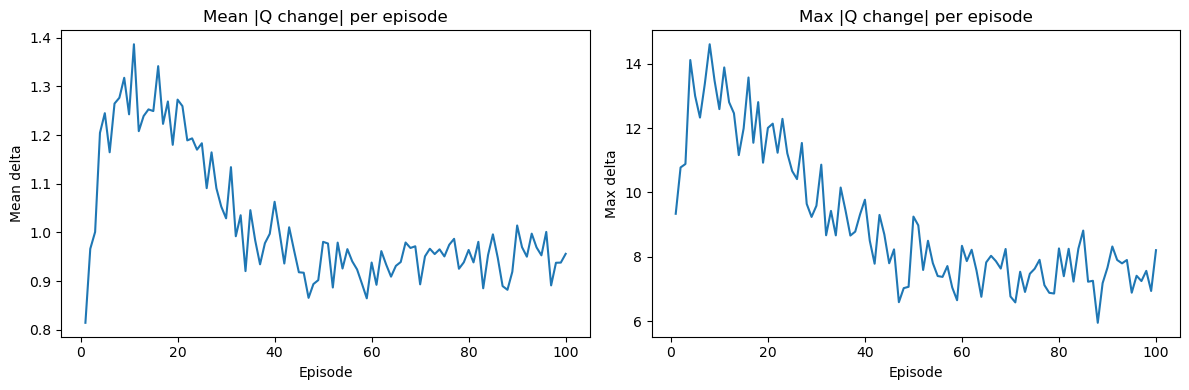


[Policy stability] States checked: 12/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 12 states -- mean: 67.1%  min: 35.0%  max: 100.0%

[Action distribution] Mean action fractions across 20 seeds (one number per action, averaged over all seeds): 33.4%, 28.2%, 38.5%
[Action distribution] Per-action spread across seeds -- min: 2.5%, 0.5%, 0.5%  max: 94.5%, 63.7%, 96.5%
[Seed degeneracy] Seeds with one action >= 95% of their own decisions: 2/20
  Which action dominates those seeds (count per action index): [0, 0, 2]

Q-learning -- best (eta, gamma): (0.0005, 0.99)


,eta,gamma,val_mean,val_std
0,0.0005,0.99,11713.7430,569.070010
1,0.0010,0.95,11697.7580,590.521907
2,0.0010,0.99,11693.3110,592.237110
3,0.0010,0.90,11650.5950,479.017623
4,0.0005,0.95,11640.5360,476.481057
5,0.0050,0.99,11587.1230,1119.921713
6,0.0005,0.90,11562.8820,346.955079
7,0.0050,0.95,10833.3720,1119.661766
8,0.0050,0.90,9912.6885,665.865620


In [36]:
q_learning_search = grid_search_hyperparameters(train_and_evaluate_greedy, eta_grid, gamma_grid, run_diagnostics=True)
print("Q-learning -- best (eta, gamma):", tuple(q_learning_search.iloc[0][["eta", "gamma"]]))
q_learning_search

In [57]:
def evaluate_best_hyperparameters(train_fn, eta_best, gamma_best, N=50, episodes=episodes,
                                    epsilon_start=epsilon, epsilon_decay=epsilon_decay, epsilon_floor=0.0):
    """Retrain N seeds on the FULL train_raw with the given (eta, gamma), evaluate on
    the true held-out test_raw, and return everything needed both for the comparison
    table and for running full diagnostics on this tuned run.
    episodes/epsilon_start/epsilon_decay/epsilon_floor default to the notebook's
    global values but can be overridden here without touching those globals."""
    train_vals = np.zeros(N)
    test_vals = np.zeros(N)
    seed_agents = []
    all_delta_history_max = []
    all_delta_history_mean = []
    all_test_actions = []

    for seed in range(N):
        agent, train_final, test_final, delta_history_max, delta_history_mean, train_actions, test_actions = train_fn(
            seed, train_raw, test_raw, episodes=episodes,
            n_bins=n_bins, n_actions=n_actions, eta=eta_best, gamma=gamma_best,
            epsilon_start=epsilon_start, epsilon_decay=epsilon_decay, epsilon_floor=epsilon_floor,
            bin_range=bin_range, n_cash_bins=n_cash_bins, cash_bin_range=cash_bin_range)
        train_vals[seed] = train_final
        test_vals[seed] = test_final
        seed_agents.append(agent)
        all_delta_history_max.append(delta_history_max)
        all_delta_history_mean.append(delta_history_mean)
        all_test_actions.append(test_actions)

    return {
        "train_results": train_vals,
        "test_results": test_vals,
        "seed_agents": seed_agents,
        "avg_delta_history_max": np.mean(all_delta_history_max, axis=0),
        "avg_delta_history_mean": np.mean(all_delta_history_mean, axis=0),
        "avg_visit_counts": np.mean([agent.visit_counts for agent in seed_agents], axis=0),
        "all_test_actions": all_test_actions,
        # the actual epsilon schedule this run used (whichever of the function's
        # defaults/overrides was actually in effect) -- stashed here so callers can pass
        # it straight into run_full_diagnostics's epsilon_start/epsilon_decay/epsilon_floor
        # for the convergence plot's floor-episode line, instead of re-deriving or guessing it
        "epsilon_start": epsilon_start,
        "epsilon_decay": epsilon_decay,
        "epsilon_floor": epsilon_floor,
    }

In [58]:
best_eta_q, best_gamma_q = q_learning_search.iloc[0][["eta", "gamma"]]
best_q = evaluate_best_hyperparameters(train_and_evaluate_greedy, best_eta_q, best_gamma_q)

In [ ]:
print(best_q['Q_value'])

#### Q-learning (tuned) diagnostics

In [ ]:
run_full_diagnostics(
    visit_counts=best_q["avg_visit_counts"],
    delta_history=best_q["avg_delta_history_max"],
    delta_history_mean=best_q["avg_delta_history_mean"],
    seed_agents=best_q["seed_agents"],
    greedy_actions=best_q["all_test_actions"],
    n_actions=n_actions,
    epsilon_start=best_q["epsilon_start"],
    epsilon_decay=best_q["epsilon_decay"],
    epsilon_floor=best_q["epsilon_floor"],
    train_results=best_q["train_results"],
    test_results=best_q["test_results"],
)

## Extended Convergence Test (Q-learning, single seed)

By episode 30 with the default `epsilon_decay=0.995`, epsilon is still at `0.995^30 ≈ 0.86` - the agent is still acting almost entirely randomly, which alone could explain why delta doesn't look converged. This test keeps `episodes=30` but decays epsilon much faster (`epsilon_decay=0.95`, giving `0.95^30 ≈ 0.215` by the end - similar residual exploration to what 300 episodes at the default decay would reach), to check whether faster epsilon decay alone is enough to reveal convergence within the same 30 episodes.

In [15]:
from diagnostics import check_convergence, plot_convergence

test_episodes = 60
test_epsilon_decay = 0.95
test_seed = 0

(agent_test, train_final_test, test_final_test,
 delta_history_max_test, delta_history_mean_test,
 train_actions_test, test_actions_test) = train_and_evaluate_greedy(
    test_seed, train_raw, test_raw, episodes=test_episodes,
    n_bins=n_bins, n_actions=n_actions, eta=eta, gamma=gamma,
    epsilon_start=epsilon, epsilon_decay=test_epsilon_decay, bin_range=bin_range,
    n_cash_bins=n_cash_bins, cash_bin_range=cash_bin_range)

print(f"Episodes = {test_episodes}, epsilon_decay = {test_epsilon_decay}, seed = {test_seed}")
print(f"Q-learning (greedy) -- Train: {train_final_test:.2f}")
print(f"Q-learning (greedy) -- Test:  {test_final_test:.2f}")

Episodes = 60, epsilon_decay = 0.95, seed = 0
Q-learning (greedy) -- Train: 10618.52
Q-learning (greedy) -- Test:  9797.46


[Convergence] Final delta: 52.372866 (NOT YET CONVERGED, consider more episodes)


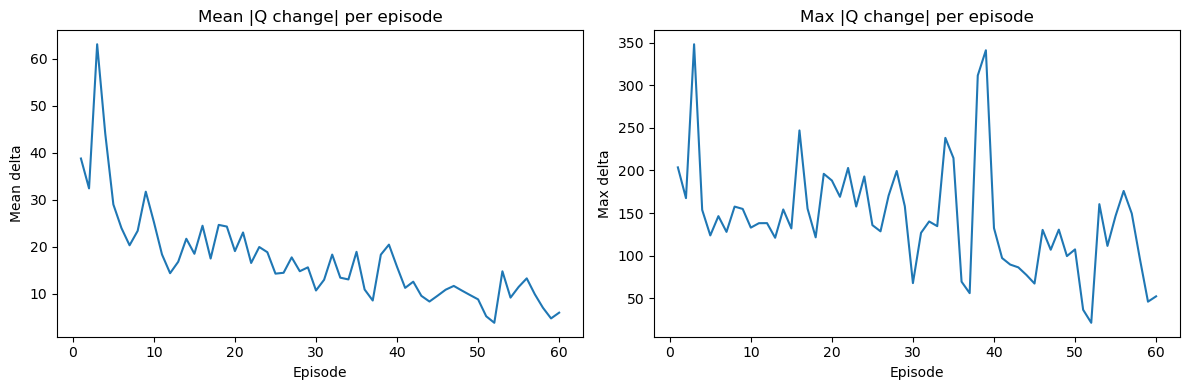

In [50]:
check_convergence(delta_history_max_test)
# epsilon_floor=0.0 here because the training call above doesn't override it -- that's
# train_and_evaluate_greedy's own default, not the notebook's global epsilon_floor
plot_convergence(delta_history_mean_test, delta_history_max_test,
                  epsilon_start=epsilon, epsilon_decay=test_epsilon_decay, epsilon_floor=0.0)

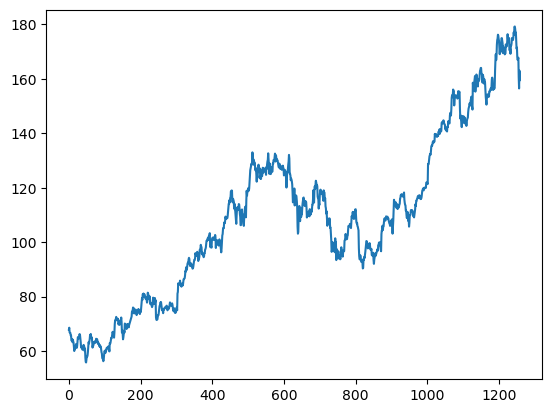

In [69]:
import matplotlib.pyplot as plt
plt.plot(stock_data[:,0])

With 30 episodes, there isn't much convergence but the model works very well. With 60 episodes, there is convergence but the model works well. This suggests that the model does a better job learning the policy after the Q learning models are trained.

There is a specific window/interval for the returns here, what happens if you go past that window or returns? Does the model still work as well? 



In [51]:
best_episodes = evaluate_best_hyperparameters(train_and_evaluate_greedy, best_eta_q, best_gamma_q, episodes=30, epsilon_decay=0.95)

NameError: name 'best_eta_q' is not defined

In [52]:
run_full_diagnostics(
    visit_counts=best_episodes["avg_visit_counts"],
    delta_history=best_episodes["avg_delta_history_max"],
    delta_history_mean=best_episodes["avg_delta_history_mean"],
    seed_agents=best_episodes["seed_agents"],
    greedy_actions=best_episodes["all_test_actions"],
    n_actions=n_actions,
    epsilon_start=best_episodes["epsilon_start"],
    epsilon_decay=best_episodes["epsilon_decay"],
    epsilon_floor=best_episodes["epsilon_floor"],
    train_results=best_episodes["train_results"],
    test_results=best_episodes["test_results"],
)

NameError: name 'best_episodes' is not defined

In [53]:
print(best_episodes['train_results'].mean(), best_episodes['train_results'].std())
print(best_episodes['test_results'].mean(), best_episodes['test_results'].std())

NameError: name 'best_episodes' is not defined

Need to check if convergence occurs so do not require epsilon decay specifically.

## Fixed Epsilon Test (Q-learning, no decay, 50 seeds)

Runs with `epsilon` held constant at 0.3 for every episode (`epsilon_decay=1.0`, so `epsilon *= 1.0` never actually changes it), instead of decaying from 1.0 down toward greedy. Uses `evaluate_best_hyperparameters` directly (N=50 seeds, averaged, full diagnostics) rather than a one-off single-seed loop.

In [23]:
test_epsilon = 1
episodes = 100
eta = 0.001
gamma = 0.95

fixed_eps_result = evaluate_best_hyperparameters(
    train_and_evaluate_greedy, eta, gamma, N=5,
    episodes=episodes, epsilon_start=test_epsilon, epsilon_decay=0.95)

print(f"Episodes = {episodes}, epsilon = {test_epsilon} (constant, no decay), seeds = {N}")
print(f"Q-learning (greedy) -- Train: mean={fixed_eps_result['train_results'].mean():.2f}, "
      f"std={fixed_eps_result['train_results'].std():.2f}")
print(f"Q-learning (greedy) -- Test:  mean={fixed_eps_result['test_results'].mean():.2f}, "
      f"std={fixed_eps_result['test_results'].std():.2f}")

Episodes = 100, epsilon = 1 (constant, no decay), seeds = 50
Q-learning (greedy) -- Train: mean=11839.72, std=173.46
Q-learning (greedy) -- Test:  mean=11597.43, std=818.51


In [ ]:
run_full_diagnostics(
    visit_counts=fixed_eps_result["avg_visit_counts"],
    delta_history=fixed_eps_result["avg_delta_history_max"],
    delta_history_mean=fixed_eps_result["avg_delta_history_mean"],
    seed_agents=fixed_eps_result["seed_agents"],
    greedy_actions=fixed_eps_result["all_test_actions"],
    n_actions=n_actions,
    epsilon_start=fixed_eps_result["epsilon_start"],
    epsilon_decay=fixed_eps_result["epsilon_decay"],
    epsilon_floor=fixed_eps_result["epsilon_floor"],
    train_results=fixed_eps_result["train_results"],
    test_results=fixed_eps_result["test_results"],
)

In [ ]:
run_full_diagnostics(
    visit_counts=best_episodes["avg_visit_counts"],
    delta_history=best_episodes["avg_delta_history_max"],
    delta_history_mean=best_episodes["avg_delta_history_mean"],
    seed_agents=best_episodes["seed_agents"],
    greedy_actions=best_episodes["all_test_actions"],
    n_actions=n_actions,
    epsilon_start=best_episodes["epsilon_start"],
    epsilon_decay=best_episodes["epsilon_decay"],
    epsilon_floor=best_episodes["epsilon_floor"],
    train_results=best_episodes["train_results"],
    test_results=best_episodes["test_results"],
)

In [ ]:
# testing how digitize works
import numpy as np
x = np.array([-1,0.2, 0.4, 3.0, 1.6])
bins = np.array([0.0, 0.5, 1][1:-1])
inds = np.digitize(x, bins)
print(inds)

[0 0 0 1 1]


In [ ]:
# The "Fixed Epsilon Test" cell above overwrites the shared episodes/eta/gamma globals
# (episodes=300, eta=0.001) for its own one-off experiment. Restore the notebook's
# standard values here so the Expected SARSA / Double Q-learning sections below train
# under the same conditions as the Q-learning section above, not the fixed-epsilon test's.
episodes = 30
eta = 0.1
gamma = 0.95

## Expected SARSA

Same agent, state, and reward as the Q-learning run above - only the update target changes. Q-learning bootstraps off `max_a' Q(s', a')` (off-policy: it evaluates the fully greedy policy regardless of how it actually behaves). Expected SARSA instead bootstraps off the *expected* value of the next state under the actual epsilon-greedy behaviour policy, `sum_a' pi(a'|s') * Q(s', a')`. This is generally lower-variance than plain SARSA (which uses a single sampled next action) while still accounting for the exploration the agent is actually doing, unlike Q-learning's max.

In [45]:
eta_grid = [0.001, 0.005, 0.01]
gamma_grid = [0.95, 0.99, 0.995]

In [46]:
def train_and_evaluate_expected_sarsa(seed, train_raw, test_raw, episodes=10, n_bins=10, n_actions=3, eta=0.1, gamma=0.95,
                        epsilon_start=1.0, epsilon_decay=0.995, epsilon_floor=0.0, bin_range=(0.9, 1.1),
                        n_cash_bins=2, cash_bin_range=(0, 1)):
    np.random.seed(seed)

    agent = Agent_basic(n_bins=n_bins, n_cash_bins=n_cash_bins, n_actions=n_actions, eta=eta, gamma=gamma)
    train_size = len(train_raw)
    epsilon = epsilon_start
    delta_history_max = []   # max|Q_new - Q_old| per episode, for the convergence diagnostic
    delta_history_mean = []  # mean|Q_new - Q_old| per episode, for the convergence diagnostic

    for ep in range(episodes):
        Q_before = agent.Q.copy()
        state = State_basic(train_raw, uninvested_cash=initial_cash, n_bins=n_bins, bin_range=bin_range,
                             n_cash_bins=n_cash_bins, cash_bin_range=cash_bin_range)
        for t in range(train_size - 1):
            s = state.get_observation(t)
            if np.random.rand() < epsilon:
                a = np.random.randint(agent.Q.shape[-1])
            else:
                a = agent.select_action(s)
            r = state.reward(a, t)
            s_next = state.get_observation(t + 1)
            agent.update_expected_sarsa(s, s_next, a, r, epsilon)
        epsilon = max(epsilon * epsilon_decay, epsilon_floor)  # decay stops here, never goes below the floor
        abs_change = np.abs(agent.Q - Q_before)
        delta_history_max.append(np.max(abs_change))
        delta_history_mean.append(np.mean(abs_change))

    train_final, train_actions = run_greedy(train_raw, agent, n_bins=n_bins, n_cash_bins=n_cash_bins, cash_bin_range=cash_bin_range)
    test_final, test_actions = run_greedy(test_raw, agent, n_bins=n_bins, n_cash_bins=n_cash_bins, cash_bin_range=cash_bin_range)

    return agent, train_final, test_final, delta_history_max, delta_history_mean, train_actions, test_actions

In [47]:
train_results_sarsa = np.zeros(N)
test_results_sarsa = np.zeros(N)
seed_agents_sarsa = []             # every seed's trained agent, for coverage / policy-stability diagnostics
all_delta_history_max_sarsa = []   # every seed's max-delta curve, averaged for the convergence diagnostic
all_delta_history_mean_sarsa = []  # every seed's mean-delta curve, averaged for the convergence diagnostic
all_test_actions_sarsa = []        # every seed's greedy test rollout, for the action-distribution diagnostic

for seed in range(N):
    agent, train_final, test_final, delta_history_max, delta_history_mean, train_actions, test_actions = train_and_evaluate_expected_sarsa(
        seed, train_raw, test_raw, episodes=episodes, n_bins=n_bins, n_actions=n_actions, eta=eta, gamma=gamma,
        epsilon_start=epsilon, epsilon_decay=epsilon_decay, epsilon_floor=epsilon_floor, bin_range=bin_range,
        n_cash_bins=n_cash_bins, cash_bin_range=cash_bin_range)
    train_results_sarsa[seed] = train_final
    test_results_sarsa[seed] = test_final
    seed_agents_sarsa.append(agent)
    all_delta_history_max_sarsa.append(delta_history_max)
    all_delta_history_mean_sarsa.append(delta_history_mean)
    all_test_actions_sarsa.append(test_actions)

avg_delta_history_max_sarsa = np.mean(all_delta_history_max_sarsa, axis=0)
avg_delta_history_mean_sarsa = np.mean(all_delta_history_mean_sarsa, axis=0)
avg_visit_counts_sarsa = np.mean([agent.visit_counts for agent in seed_agents_sarsa], axis=0)

print(f"Episodes = {episodes}")
print(f"Expected SARSA (greedy) -- Train: mean={train_results_sarsa.mean():.2f}, std={train_results_sarsa.std():.2f}")
print(f"Expected SARSA (greedy) -- Test:  mean={test_results_sarsa.mean():.2f}, std={test_results_sarsa.std():.2f}")

Episodes = 100
Expected SARSA (greedy) -- Train: mean=10720.20, std=456.72
Expected SARSA (greedy) -- Test:  mean=10441.93, std=705.50


DIAGNOSTIC CHECKLIST
[Train/Test] Train -- mean: 10720.20  std: 456.72
[Train/Test] Test  -- mean: 10441.93  std: 705.50

[Coverage] Unvisited (state, action) pairs: 12 / 60 (20.0%)
  Unvisited pairs (state..., action): [(np.int64(0), np.int64(0), np.int64(0)), (np.int64(0), np.int64(0), np.int64(1)), (np.int64(0), np.int64(0), np.int64(2)), (np.int64(0), np.int64(1), np.int64(0)), (np.int64(0), np.int64(1), np.int64(1)), (np.int64(0), np.int64(1), np.int64(2)), (np.int64(9), np.int64(0), np.int64(0)), (np.int64(9), np.int64(0), np.int64(1)), (np.int64(9), np.int64(0), np.int64(2)), (np.int64(9), np.int64(1), np.int64(0))] ...



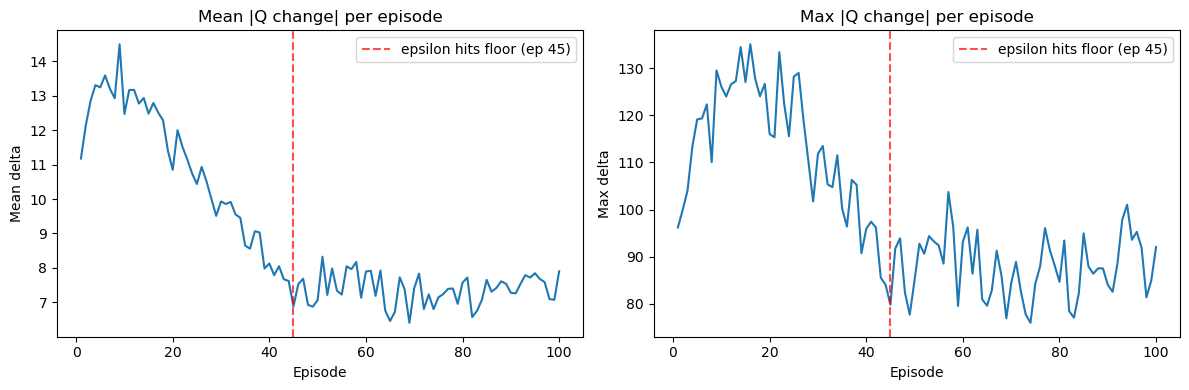


[Policy stability] States checked: 12/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 12 states -- mean: 66.7%  min: 42.0%  max: 100.0%



In [40]:
run_full_diagnostics(
    visit_counts=avg_visit_counts_sarsa,
    delta_history=avg_delta_history_max_sarsa,
    delta_history_mean=avg_delta_history_mean_sarsa,
    seed_agents=seed_agents_sarsa,
    greedy_actions=all_test_actions_sarsa,
    n_actions=n_actions,
    epsilon_start=epsilon,
    epsilon_decay=epsilon_decay,
    epsilon_floor=epsilon_floor,
    train_results=train_results_sarsa,
    test_results=test_results_sarsa,
)

## Double Q-learning

Standard Q-learning uses the same Q-table both to pick the best next action (`argmax`) and to evaluate it (`Q(s', argmax_a Q(s',a))`), which systematically overestimates values under noise (maximization bias). Double Q-learning keeps two independent tables, `Q_a` and `Q_b`. Each update picks one table at random to update, using *its own* argmax action but looking up that action's value in the *other* table - decoupling "which action looks best" from "how good is that action actually," which removes the bias. Action selection (both during training's greedy branch and at evaluation time) uses the average of the two tables.

In [41]:
class Agent_double_q:
    def __init__(self, n_bins, n_cash_bins, n_actions=3, eta=0.1, gamma=0.95):
        self.Q_a = np.zeros((n_bins, n_cash_bins, n_actions))
        self.Q_b = np.zeros((n_bins, n_cash_bins, n_actions))
        self.visit_counts = np.zeros((n_bins, n_cash_bins, n_actions), dtype=int)  # for the coverage diagnostic
        self.eta = eta
        self.gamma = gamma

    # property is a wrapper to make agent_action work
    @property
    def Q(self):
        # combined estimate used for action selection, and for the diagnostics module
        # (coverage / policy stability / Q-gap checks all just read agent.Q)
        return (self.Q_a + self.Q_b) / 2

    def select_action(self, s):
        return np.argmax(self.Q[s])   # s is a (return_bin, cash_bin) tuple

    def update(self, s, s_next, a, r):
        # flip a coin to decide which table gets updated this step, using the OTHER table
        # to evaluate the chosen action - decouples action selection from value estimation
        if np.random.rand() < 0.5:
            a_star = np.argmax(self.Q_a[s_next])
            target = r + self.gamma * self.Q_b[s_next][a_star]
            self.Q_a[s][a] = self.Q_a[s][a] + self.eta * (target - self.Q_a[s][a])
        else:
            b_star = np.argmax(self.Q_b[s_next])
            target = r + self.gamma * self.Q_a[s_next][b_star]
            self.Q_b[s][a] = self.Q_b[s][a] + self.eta * (target - self.Q_b[s][a])
        self.visit_counts[s][a] += 1

In [42]:
def train_and_evaluate_double_q(seed, train_raw, test_raw, episodes=10, n_bins=10, n_actions=3, eta=0.1, gamma=0.95,
                        epsilon_start=1.0, epsilon_decay=0.995, epsilon_floor=0.0, bin_range=(0.9, 1.1),
                        n_cash_bins=2, cash_bin_range=(0, 1)):
    np.random.seed(seed)

    agent = Agent_double_q(n_bins=n_bins, n_cash_bins=n_cash_bins, n_actions=n_actions, eta=eta, gamma=gamma)
    train_size = len(train_raw)
    epsilon = epsilon_start
    delta_history_max = []   # max|Q_new - Q_old| per episode (on the averaged Q), for the convergence diagnostic
    delta_history_mean = []  # mean|Q_new - Q_old| per episode (on the averaged Q), for the convergence diagnostic

    for ep in range(episodes):
        Q_before = agent.Q.copy()
        state = State_basic(train_raw, uninvested_cash=initial_cash, n_bins=n_bins, bin_range=bin_range,
                             n_cash_bins=n_cash_bins, cash_bin_range=cash_bin_range)
        for t in range(train_size - 1):
            s = state.get_observation(t)
            if np.random.rand() < epsilon:
                a = np.random.randint(agent.Q_a.shape[-1])   # pulls n_actions from the agent, not a hardcoded 3
            else:
                a = agent.select_action(s)
            r = state.reward(a, t)
            s_next = state.get_observation(t + 1)
            agent.update(s, s_next, a, r)
        epsilon = max(epsilon * epsilon_decay, epsilon_floor)  # decay stops here, never goes below the floor
        abs_change = np.abs(agent.Q - Q_before)
        delta_history_max.append(np.max(abs_change))
        delta_history_mean.append(np.mean(abs_change))

    train_final, train_actions = run_greedy(train_raw, agent, n_bins=n_bins, n_cash_bins=n_cash_bins, cash_bin_range=cash_bin_range)
    test_final, test_actions = run_greedy(test_raw, agent, n_bins=n_bins, n_cash_bins=n_cash_bins, cash_bin_range=cash_bin_range)

    return agent, train_final, test_final, delta_history_max, delta_history_mean, train_actions, test_actions

In [43]:
train_results_double_q = np.zeros(N)
test_results_double_q = np.zeros(N)
seed_agents_double_q = []             # every seed's trained agent, for coverage / policy-stability diagnostics
all_delta_history_max_double_q = []   # every seed's max-delta curve, averaged for the convergence diagnostic
all_delta_history_mean_double_q = []  # every seed's mean-delta curve, averaged for the convergence diagnostic
all_test_actions_double_q = []        # every seed's greedy test rollout, for the action-distribution diagnostic

for seed in range(N):
    agent, train_final, test_final, delta_history_max, delta_history_mean, train_actions, test_actions = train_and_evaluate_double_q(
        seed, train_raw, test_raw, episodes=episodes, n_bins=n_bins, n_actions=n_actions, eta=eta, gamma=gamma,
        epsilon_start=epsilon, epsilon_decay=epsilon_decay, epsilon_floor=epsilon_floor, bin_range=bin_range,
        n_cash_bins=n_cash_bins, cash_bin_range=cash_bin_range)
    train_results_double_q[seed] = train_final
    test_results_double_q[seed] = test_final
    seed_agents_double_q.append(agent)
    all_delta_history_max_double_q.append(delta_history_max)
    all_delta_history_mean_double_q.append(delta_history_mean)
    all_test_actions_double_q.append(test_actions)

avg_delta_history_max_double_q = np.mean(all_delta_history_max_double_q, axis=0)
avg_delta_history_mean_double_q = np.mean(all_delta_history_mean_double_q, axis=0)
avg_visit_counts_double_q = np.mean([agent.visit_counts for agent in seed_agents_double_q], axis=0)

print(f"Episodes = {episodes}")
print(f"Double Q-learning (greedy) -- Train: mean={train_results_double_q.mean():.2f}, std={train_results_double_q.std():.2f}")
print(f"Double Q-learning (greedy) -- Test:  mean={test_results_double_q.mean():.2f}, std={test_results_double_q.std():.2f}")

Episodes = 100
Double Q-learning (greedy) -- Train: mean=10655.17, std=567.23
Double Q-learning (greedy) -- Test:  mean=10454.57, std=779.12


DIAGNOSTIC CHECKLIST
[Train/Test] Train -- mean: 10655.17  std: 567.23
[Train/Test] Test  -- mean: 10454.57  std: 779.12

[Coverage] Unvisited (state, action) pairs: 12 / 60 (20.0%)
  Unvisited pairs (state..., action): [(np.int64(0), np.int64(0), np.int64(0)), (np.int64(0), np.int64(0), np.int64(1)), (np.int64(0), np.int64(0), np.int64(2)), (np.int64(0), np.int64(1), np.int64(0)), (np.int64(0), np.int64(1), np.int64(1)), (np.int64(0), np.int64(1), np.int64(2)), (np.int64(9), np.int64(0), np.int64(0)), (np.int64(9), np.int64(0), np.int64(1)), (np.int64(9), np.int64(0), np.int64(2)), (np.int64(9), np.int64(1), np.int64(0))] ...



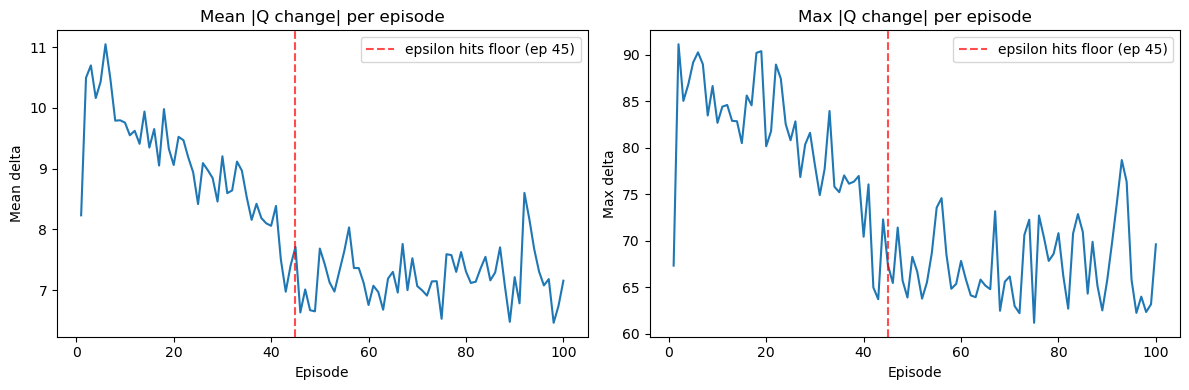


[Policy stability] States checked: 12/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 12 states -- mean: 59.3%  min: 38.0%  max: 92.0%

[Double Q agreement] Seeds scored (had states with >= 100 visits): 50/50
[Double Q agreement] Mean |Q_a - Q_b| on well-sampled states -- mean: 34.1808  min: 18.5046  max: 48.8541
[Double Q agreement] Q_a vs Q_b greedy-action agreement -- mean: 58.2%  min: 25.0%  max: 91.7%


np.float64(0.5816666666666667)

In [44]:
from diagnostics import check_double_q_agreement

run_full_diagnostics(
    visit_counts=avg_visit_counts_double_q,
    delta_history=avg_delta_history_max_double_q,
    delta_history_mean=avg_delta_history_mean_double_q,
    seed_agents=seed_agents_double_q,
    greedy_actions=all_test_actions_double_q,
    n_actions=n_actions,
    epsilon_start=epsilon,
    epsilon_decay=epsilon_decay,
    epsilon_floor=epsilon_floor,
    train_results=train_results_double_q,
    test_results=test_results_double_q,
)

check_double_q_agreement(seed_agents_double_q)

Clearly using a discrete state space doesn't make much sense for a continuous variable. It seems like the data has overfitted to the training value.

In [54]:
import pandas as pd

strategies = {
    "Buy & Hold": (np.array([buy_hold_train]), np.array([buy_hold_test])),
    "Random": (random_train_results, random_test_results),
    "Q-learning": (train_results, test_results),
    "Double Q-learning": (train_results_double_q, test_results_double_q),
    "Expected SARSA": (train_results_sarsa, test_results_sarsa),
}

summary_rows = []
for name, (train_vals, test_vals) in strategies.items():
    summary_rows.append({
        "Strategy": name,
        "Train mean": train_vals.mean(),
        "Train std": train_vals.std(),
        "Test mean": test_vals.mean(),
        "Test std": test_vals.std(),
    })

summary_df = pd.DataFrame(summary_rows).set_index("Strategy").round(2)
summary_df

,Train mean,Train std,Test mean,Test std
Strategy,,,,
Buy & Hold,11799.70,0.00,12071.51,0.00
Random,11002.82,654.10,11157.88,1106.48
Q-learning,10938.47,541.28,10553.55,768.94
Double Q-learning,10655.17,567.23,10454.57,779.12
Expected SARSA,10720.20,456.72,10441.93,705.50


In [ ]:
eta

In [55]:
eta_grid = [0.001, 0.005, 0.01]
gamma_grid = [0.95, 0.99, 0.995]


--- eta=0.001, gamma=0.95 ---
DIAGNOSTIC CHECKLIST
[Train/Test] SKIPPED -- pass train_results and test_results to enable

[Coverage] Unvisited (state, action) pairs: 12 / 60 (20.0%)
  Unvisited pairs (state..., action): [(np.int64(0), np.int64(0), np.int64(0)), (np.int64(0), np.int64(0), np.int64(1)), (np.int64(0), np.int64(0), np.int64(2)), (np.int64(0), np.int64(1), np.int64(0)), (np.int64(0), np.int64(1), np.int64(1)), (np.int64(0), np.int64(1), np.int64(2)), (np.int64(9), np.int64(0), np.int64(0)), (np.int64(9), np.int64(0), np.int64(1)), (np.int64(9), np.int64(0), np.int64(2)), (np.int64(9), np.int64(1), np.int64(0))] ...



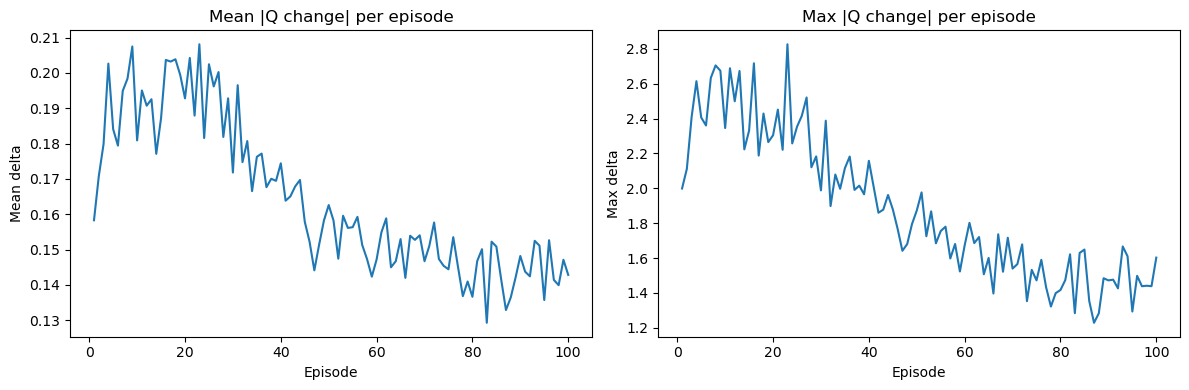


[Policy stability] States checked: 12/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 12 states -- mean: 73.8%  min: 45.0%  max: 100.0%


--- eta=0.001, gamma=0.99 ---
DIAGNOSTIC CHECKLIST
[Train/Test] SKIPPED -- pass train_results and test_results to enable

[Coverage] Unvisited (state, action) pairs: 12 / 60 (20.0%)
  Unvisited pairs (state..., action): [(np.int64(0), np.int64(0), np.int64(0)), (np.int64(0), np.int64(0), np.int64(1)), (np.int64(0), np.int64(0), np.int64(2)), (np.int64(0), np.int64(1), np.int64(0)), (np.int64(0), np.int64(1), np.int64(1)), (np.int64(0), np.int64(1), np.int64(2)), (np.int64(9), np.int64(0), np.int64(0)), (np.int64(9), np.int64(0), np.int64(1)), (np.int64(9), np.int64(0), np.int64(2)), (np.int64(9), np.int64(1), np.int64(0))] ...



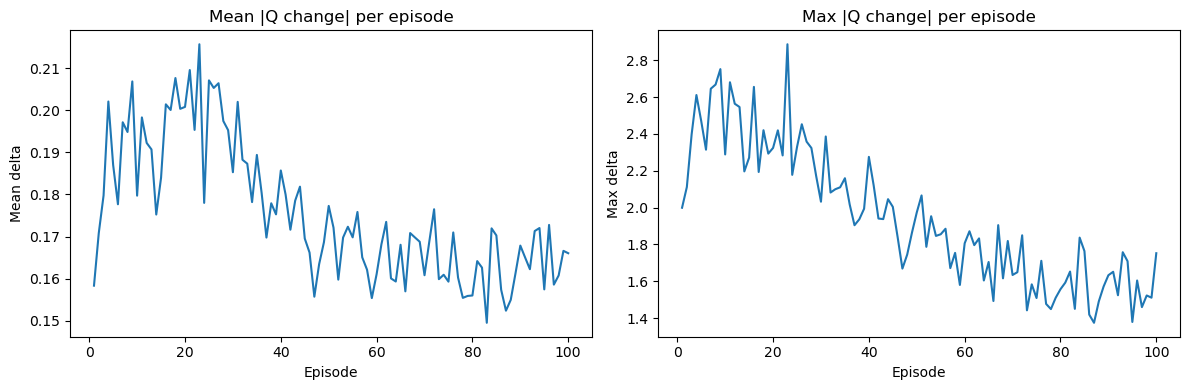


[Policy stability] States checked: 12/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 12 states -- mean: 73.3%  min: 40.0%  max: 100.0%


--- eta=0.001, gamma=0.995 ---
DIAGNOSTIC CHECKLIST
[Train/Test] SKIPPED -- pass train_results and test_results to enable

[Coverage] Unvisited (state, action) pairs: 12 / 60 (20.0%)
  Unvisited pairs (state..., action): [(np.int64(0), np.int64(0), np.int64(0)), (np.int64(0), np.int64(0), np.int64(1)), (np.int64(0), np.int64(0), np.int64(2)), (np.int64(0), np.int64(1), np.int64(0)), (np.int64(0), np.int64(1), np.int64(1)), (np.int64(0), np.int64(1), np.int64(2)), (np.int64(9), np.int64(0), np.int64(0)), (np.int64(9), np.int64(0), np.int64(1)), (np.int64(9), np.int64(0), np.int64(2)), (np.int64(9), np.int64(1), np.int64(0))] ...



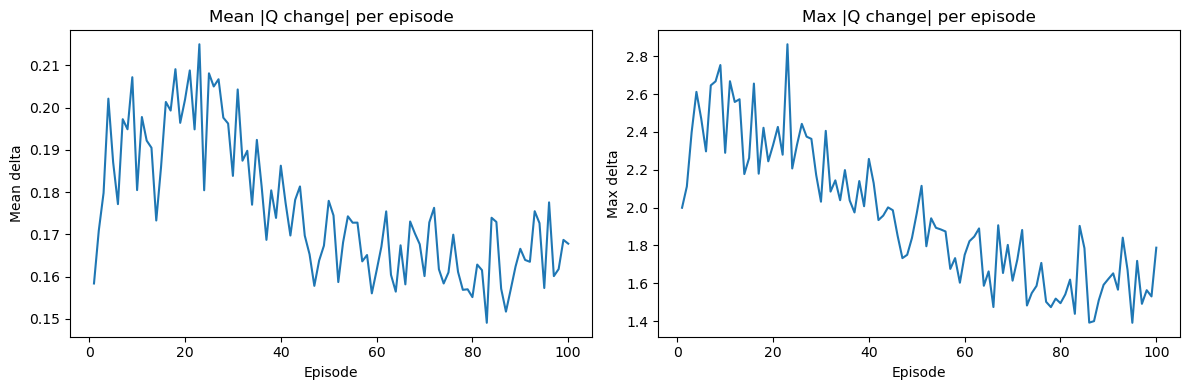


[Policy stability] States checked: 12/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 12 states -- mean: 73.3%  min: 40.0%  max: 100.0%


--- eta=0.005, gamma=0.95 ---
DIAGNOSTIC CHECKLIST
[Train/Test] SKIPPED -- pass train_results and test_results to enable

[Coverage] Unvisited (state, action) pairs: 12 / 60 (20.0%)
  Unvisited pairs (state..., action): [(np.int64(0), np.int64(0), np.int64(0)), (np.int64(0), np.int64(0), np.int64(1)), (np.int64(0), np.int64(0), np.int64(2)), (np.int64(0), np.int64(1), np.int64(0)), (np.int64(0), np.int64(1), np.int64(1)), (np.int64(0), np.int64(1), np.int64(2)), (np.int64(9), np.int64(0), np.int64(0)), (np.int64(9), np.int64(0), np.int64(1)), (np.int64(9), np.int64(0), np.int64(2)), (np.int64(9), np.int64(1), np.int64(0))] ...



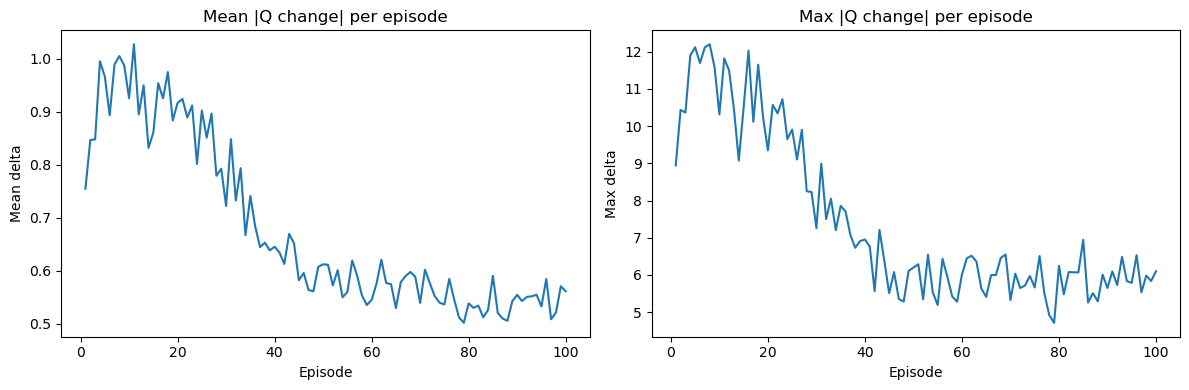


[Policy stability] States checked: 12/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 12 states -- mean: 74.2%  min: 45.0%  max: 100.0%


--- eta=0.005, gamma=0.99 ---
DIAGNOSTIC CHECKLIST
[Train/Test] SKIPPED -- pass train_results and test_results to enable

[Coverage] Unvisited (state, action) pairs: 12 / 60 (20.0%)
  Unvisited pairs (state..., action): [(np.int64(0), np.int64(0), np.int64(0)), (np.int64(0), np.int64(0), np.int64(1)), (np.int64(0), np.int64(0), np.int64(2)), (np.int64(0), np.int64(1), np.int64(0)), (np.int64(0), np.int64(1), np.int64(1)), (np.int64(0), np.int64(1), np.int64(2)), (np.int64(9), np.int64(0), np.int64(0)), (np.int64(9), np.int64(0), np.int64(1)), (np.int64(9), np.int64(0), np.int64(2)), (np.int64(9), np.int64(1), np.int64(0))] ...



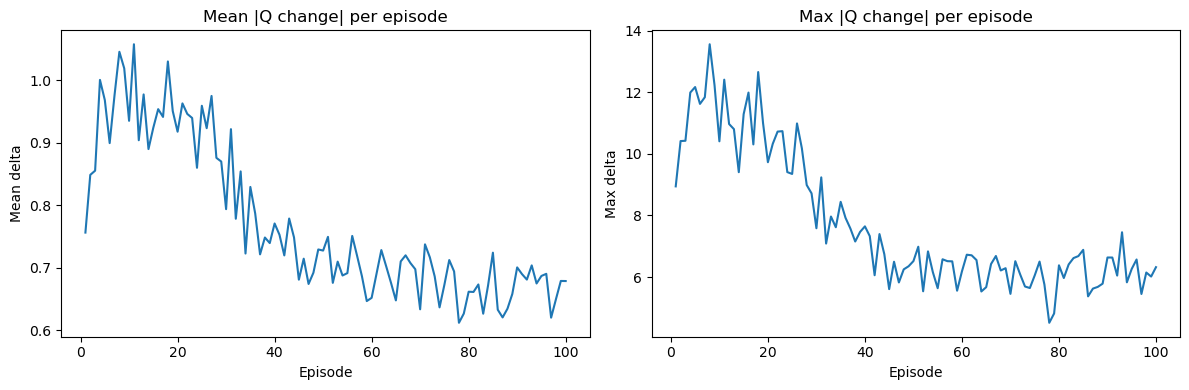


[Policy stability] States checked: 12/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 12 states -- mean: 70.0%  min: 40.0%  max: 100.0%


--- eta=0.005, gamma=0.995 ---
DIAGNOSTIC CHECKLIST
[Train/Test] SKIPPED -- pass train_results and test_results to enable

[Coverage] Unvisited (state, action) pairs: 12 / 60 (20.0%)
  Unvisited pairs (state..., action): [(np.int64(0), np.int64(0), np.int64(0)), (np.int64(0), np.int64(0), np.int64(1)), (np.int64(0), np.int64(0), np.int64(2)), (np.int64(0), np.int64(1), np.int64(0)), (np.int64(0), np.int64(1), np.int64(1)), (np.int64(0), np.int64(1), np.int64(2)), (np.int64(9), np.int64(0), np.int64(0)), (np.int64(9), np.int64(0), np.int64(1)), (np.int64(9), np.int64(0), np.int64(2)), (np.int64(9), np.int64(1), np.int64(0))] ...



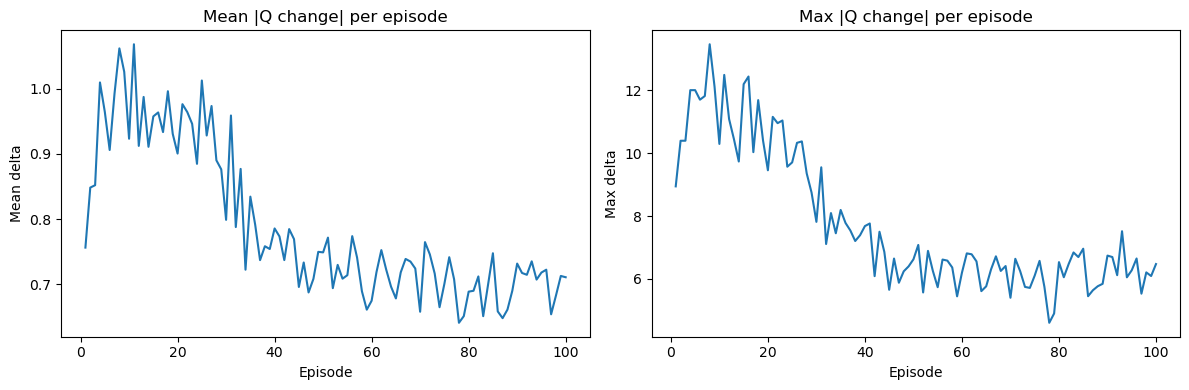


[Policy stability] States checked: 12/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 12 states -- mean: 70.0%  min: 40.0%  max: 100.0%


--- eta=0.01, gamma=0.95 ---
DIAGNOSTIC CHECKLIST
[Train/Test] SKIPPED -- pass train_results and test_results to enable

[Coverage] Unvisited (state, action) pairs: 12 / 60 (20.0%)
  Unvisited pairs (state..., action): [(np.int64(0), np.int64(0), np.int64(0)), (np.int64(0), np.int64(0), np.int64(1)), (np.int64(0), np.int64(0), np.int64(2)), (np.int64(0), np.int64(1), np.int64(0)), (np.int64(0), np.int64(1), np.int64(1)), (np.int64(0), np.int64(1), np.int64(2)), (np.int64(9), np.int64(0), np.int64(0)), (np.int64(9), np.int64(0), np.int64(1)), (np.int64(9), np.int64(0), np.int64(2)), (np.int64(9), np.int64(1), np.int64(0))] ...



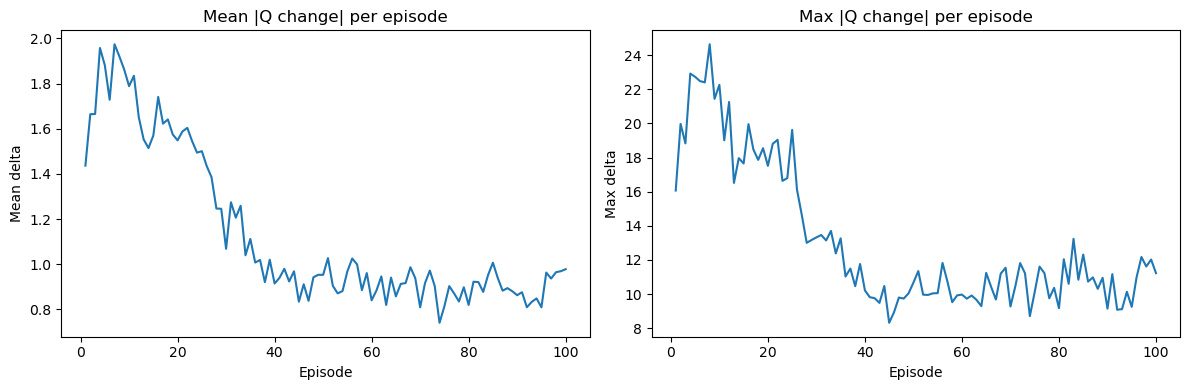


[Policy stability] States checked: 12/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 12 states -- mean: 70.0%  min: 40.0%  max: 100.0%


--- eta=0.01, gamma=0.99 ---
DIAGNOSTIC CHECKLIST
[Train/Test] SKIPPED -- pass train_results and test_results to enable

[Coverage] Unvisited (state, action) pairs: 12 / 60 (20.0%)
  Unvisited pairs (state..., action): [(np.int64(0), np.int64(0), np.int64(0)), (np.int64(0), np.int64(0), np.int64(1)), (np.int64(0), np.int64(0), np.int64(2)), (np.int64(0), np.int64(1), np.int64(0)), (np.int64(0), np.int64(1), np.int64(1)), (np.int64(0), np.int64(1), np.int64(2)), (np.int64(9), np.int64(0), np.int64(0)), (np.int64(9), np.int64(0), np.int64(1)), (np.int64(9), np.int64(0), np.int64(2)), (np.int64(9), np.int64(1), np.int64(0))] ...



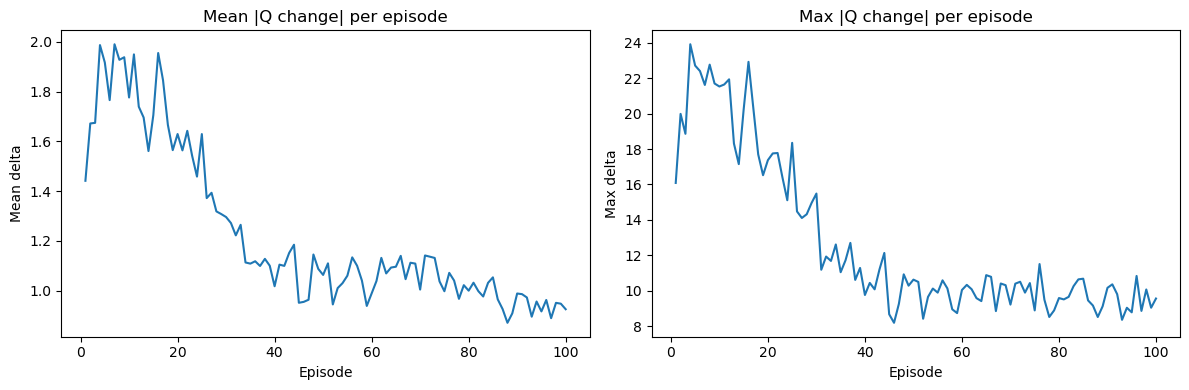


[Policy stability] States checked: 12/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 12 states -- mean: 70.0%  min: 40.0%  max: 100.0%


--- eta=0.01, gamma=0.995 ---
DIAGNOSTIC CHECKLIST
[Train/Test] SKIPPED -- pass train_results and test_results to enable

[Coverage] Unvisited (state, action) pairs: 12 / 60 (20.0%)
  Unvisited pairs (state..., action): [(np.int64(0), np.int64(0), np.int64(0)), (np.int64(0), np.int64(0), np.int64(1)), (np.int64(0), np.int64(0), np.int64(2)), (np.int64(0), np.int64(1), np.int64(0)), (np.int64(0), np.int64(1), np.int64(1)), (np.int64(0), np.int64(1), np.int64(2)), (np.int64(9), np.int64(0), np.int64(0)), (np.int64(9), np.int64(0), np.int64(1)), (np.int64(9), np.int64(0), np.int64(2)), (np.int64(9), np.int64(1), np.int64(0))] ...



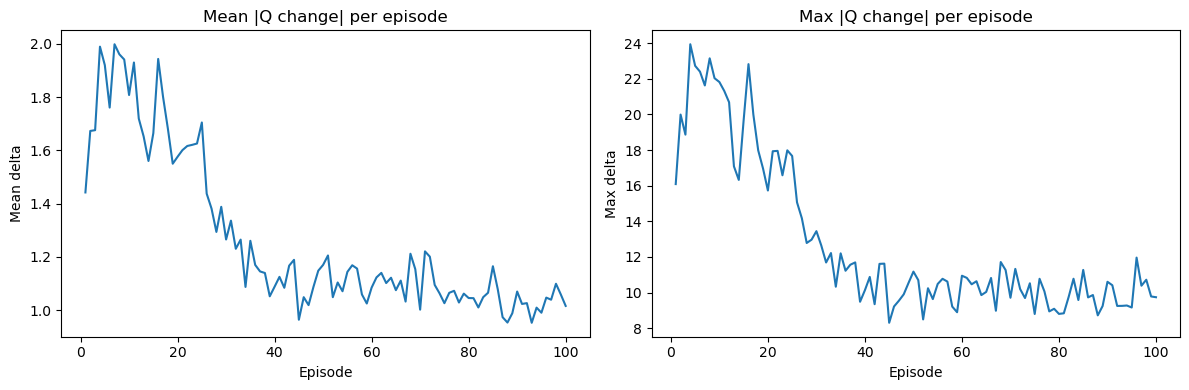


[Policy stability] States checked: 12/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 12 states -- mean: 69.2%  min: 45.0%  max: 100.0%

Expected SARSA -- best (eta, gamma): (0.001, 0.995)


,eta,gamma,val_mean,val_std
0,0.001,0.995,11567.3290,345.701012
1,0.001,0.990,11489.6750,38.512150
2,0.001,0.950,11405.2645,404.880081
3,0.005,0.990,10790.2500,867.295804
4,0.005,0.995,10790.2500,867.295804
5,0.005,0.950,10595.4670,901.117463
6,0.010,0.995,10032.3160,766.092455
7,0.010,0.950,9915.6235,539.167286
8,0.010,0.990,9890.3175,532.737702


In [56]:
sarsa_search = grid_search_hyperparameters(train_and_evaluate_expected_sarsa, eta_grid, gamma_grid, run_diagnostics=True)
print("Expected SARSA -- best (eta, gamma):", tuple(sarsa_search.iloc[0][["eta", "gamma"]]))
sarsa_search

In [ ]:
best_eta_sarsa, best_gamma_sarsa = sarsa_search.iloc[0][["eta", "gamma"]]
best_sarsa = evaluate_best_hyperparameters(train_and_evaluate_expected_sarsa, best_eta_sarsa, best_gamma_sarsa)

#### Expected SARSA (tuned) diagnostics

In [ ]:
run_full_diagnostics(
    visit_counts=best_sarsa["avg_visit_counts"],
    delta_history=best_sarsa["avg_delta_history_max"],
    delta_history_mean=best_sarsa["avg_delta_history_mean"],
    seed_agents=best_sarsa["seed_agents"],
    greedy_actions=best_sarsa["all_test_actions"],
    n_actions=n_actions,
    epsilon_start=best_sarsa["epsilon_start"],
    epsilon_decay=best_sarsa["epsilon_decay"],
    epsilon_floor=best_sarsa["epsilon_floor"],
    train_results=best_sarsa["train_results"],
    test_results=best_sarsa["test_results"],
)

In [ ]:
double_q_search = grid_search_hyperparameters(train_and_evaluate_double_q, eta_grid, gamma_grid, run_diagnostics=True)
print("Double Q-learning -- best (eta, gamma):", tuple(double_q_search.iloc[0][["eta", "gamma"]]))
double_q_search

In [ ]:
best_eta_dq, best_gamma_dq = double_q_search.iloc[0][["eta", "gamma"]]
best_dq = evaluate_best_hyperparameters(train_and_evaluate_double_q, best_eta_dq, best_gamma_dq)

#### Double Q-learning (tuned) diagnostics

In [ ]:
run_full_diagnostics(
    visit_counts=best_dq["avg_visit_counts"],
    delta_history=best_dq["avg_delta_history_max"],
    delta_history_mean=best_dq["avg_delta_history_mean"],
    seed_agents=best_dq["seed_agents"],
    greedy_actions=best_dq["all_test_actions"],
    n_actions=n_actions,
    epsilon_start=best_dq["epsilon_start"],
    epsilon_decay=best_dq["epsilon_decay"],
    epsilon_floor=best_dq["epsilon_floor"],
    train_results=best_dq["train_results"],
    test_results=best_dq["test_results"],
)

check_double_q_agreement(best_dq["seed_agents"])

### Final Comparison Using Tuned Hyperparameters

Takes only the top (eta, gamma) row from each of the three searches above, retrains N=50 seeds on the *full* `train_raw` with those values, and evaluates on the true held-out `test_raw` for the first time - the validation runs above never touched it.

In [ ]:
best_strategies = {
    "Buy & Hold": (np.array([buy_hold_train]), np.array([buy_hold_test]), None, None),
    "Random": (random_train_results, random_test_results, None, None),
    "Q-learning (tuned)": (best_q["train_results"], best_q["test_results"], best_eta_q, best_gamma_q),
    "Expected SARSA (tuned)": (best_sarsa["train_results"], best_sarsa["test_results"], best_eta_sarsa, best_gamma_sarsa),
    "Double Q-learning (tuned)": (best_dq["train_results"], best_dq["test_results"], best_eta_dq, best_gamma_dq),
}

best_rows = []
for name, (train_vals, test_vals, eta_b, gamma_b) in best_strategies.items():
    best_rows.append({
        "Strategy": name,
        "eta": eta_b,
        "gamma": gamma_b,
        "Train mean": train_vals.mean(),
        "Train std": train_vals.std(),
        "Test mean": test_vals.mean(),
        "Test std": test_vals.std(),
    })

best_comparison_df = pd.DataFrame(best_rows).set_index("Strategy").round(4)
best_comparison_df